In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


%% [markdown]
#  환자군 필터링
# 1. **Desaturated (산소 불포화 군):
#    - 최소 1회 이상 'apnea' 관련 진단/이벤트 기록이 있고,
#    - 수면 중 최저 혈중 산소포화도(SpO2)가 90% 미만으로 떨어진 환자.
# 2. **Undesaturated (정상 대조군)**:
#    - 전 수면 통틀어 'apnea' 관련 기록이 '전혀' 없고,
#    - 최저 혈중 산소포화도가 95% 이상으로 상시 유지된 환자.

# 15개의 파일을 이용해서 전처리하는 코드

# Positive(Desaturated) Group
PSG 전체에서 **Apnea** 이벤트가 최소 1회 이상 존재
해당 Oxygen Desaturation 동안 SpO₂가 90% 미만으로 감소

# 모든 stage 한 번에 처리할 수 있는 positive 구하는 코드

In [ ]:
pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 50.2 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
import os
import glob

male_folder = r"/content/drive/MyDrive/Sleep_Project/example/new/males"
female_folder = r"/content/drive/MyDrive/Sleep_Project/example/new/female"

tsv_folder = r"/content/drive/MyDrive/Sleep_Project/physionet.org/files/nch-sleep/3.1.0/Sleep_Data"

edf_files = sorted(
    glob.glob(os.path.join(male_folder, "*.edf")) +
    glob.glob(os.path.join(female_folder, "*.edf"))
)

print(f"Total EDF : {len(edf_files)}")

Total EDF : 100


In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import mne

# ===================================================
# 설정
# ===================================================

STAGES = ["N1", "N2", "N3", "REM"]

#edf_folder = r"/content/drive/MyDrive/Sleep_Project/example/new/males"
#tsv_folder = r"/content/drive/MyDrive/Sleep_Project/physionet.org/files/nch-sleep/3.1.0/Sleep_Data"

#edf_files = sorted(glob.glob(os.path.join(edf_folder, "*.edf")))

summary = []

# ===================================================
# Positive Subject Selection
# ===================================================

for edf_file in edf_files:

    patient = os.path.splitext(os.path.basename(edf_file))[0]

    tsv_file = os.path.join(tsv_folder, patient + ".tsv")

    if not os.path.exists(tsv_file):
        continue

    print(patient)

    raw = mne.io.read_raw_edf(
        edf_file,
        preload=False,
        verbose=False
    )

    # --------------------------------------------------
    # SpO2 채널이 없는(OSAT) 파일 제외
    # --------------------------------------------------

    if "SpO2" not in raw.ch_names:
        print("   -> skip (OSAT)")
        continue

    sf = int(raw.info["sfreq"])

    spo2 = raw.get_data(picks=["SpO2"])[0]

    ann = pd.read_csv(tsv_file, sep="\t")

    # --------------------------------------------------
    # Sleep Stage
    # --------------------------------------------------

    sleep = ann[
        ann["description"].str.contains("Sleep stage", na=False)
    ].copy()

    stage_map = {
        "Sleep stage W": "W",
        "Sleep stage 1": "N1",
        "Sleep stage 2": "N2",
        "Sleep stage 3": "N3",
        "Sleep stage R": "REM",
        "Sleep stage N1": "N1",
        "Sleep stage N2": "N2",
        "Sleep stage N3": "N3",
    }

    sleep["stage"] = sleep["description"].map(stage_map)

    sleep = sleep.dropna(subset=["stage"])

    sleep = sleep.sort_values("onset")

    # --------------------------------------------------
    # Apnea 여부
    # --------------------------------------------------

    apnea_exists = ann["description"].str.contains(
        r"\bApnea\b",
        regex=True,
        case=False,
        na=False
    ).any()

    # --------------------------------------------------
    # Oxygen Desaturation Event
    # --------------------------------------------------

    desat = ann[
        ann["description"] == "Oxygen Desaturation"
    ].copy()

    # Sleep Stage 붙이기
    if len(desat) > 0:

        desat = pd.merge_asof(
            desat.sort_values("onset"),
            sleep[["onset", "stage"]],
            on="onset",
            direction="backward"
        )

    # ==================================================
    # 모든 Sleep Stage 수행
    # ==================================================

    for stage in STAGES:

        # 해당 Stage의 Desaturation만 선택
        if len(desat) == 0:

            desat_stage = pd.DataFrame()

        else:

            desat_stage = desat[
                desat["stage"] == stage
            ].copy()

        # 이벤트가 하나도 없는 경우
        if len(desat_stage) == 0:

            summary.append({

                "patient": patient,

                "stage": stage,

                "apnea": apnea_exists,

                "stage_desaturation": False,

                "event_count": 0,

                "min_spo2": np.nan,

                "positive": False

            })

            continue

        mins = []

        # Stage 내 모든 Desaturation 검사
        for _, row in desat_stage.iterrows():

            start = int(row["onset"] * sf)

            end = int((row["onset"] + row["duration"]) * sf)

            segment = spo2[start:end]

            # 0은 결측값 제거, 50 이하도 없애버림
            #segment = segment[segment > 0]
            segment = segment[(segment >= 50) & (segment <= 100)]
            if len(segment) == 0:
                continue

            mins.append(segment.min())

        patient_min = np.min(mins) if len(mins) > 0 else np.nan

        positive = (

            apnea_exists

            and

            len(mins) > 0

            and

            patient_min < 90

        )

        summary.append({

            "patient": patient,

            "stage": stage,

            "apnea": apnea_exists,

            "stage_desaturation": len(mins) > 0,

            "event_count": len(mins),

            "min_spo2": patient_min,

            "positive": positive

        })

# ===================================================
# 결과
# ===================================================

summary = pd.DataFrame(summary)

print("\n============================")
print(summary)

print("\n============================")
print("Positive Subjects")

print(summary[summary["positive"]])

summary.to_csv(
    "positive_subjects_all_stage.csv",
    index=False
)

10297_20458
10384_18907
   -> skip (OSAT)
11980_6088
12304_4792
13279_15115
13675_18847
   -> skip (OSAT)
14041_9991
   -> skip (OSAT)
14314_202
14872_2584
1498_6517
15133_24859
15727_3658
15985_17278
160_2740
16225_10300
16342_12895
   -> skip (OSAT)
17392_16759
17434_3148
17548_12853
   -> skip (OSAT)
17569_21556
17623_4480
18604_5737
18985_8851
1912_8209
19447_16972
   -> skip (OSAT)
19561_6895
   -> skip (OSAT)
19975_23428
   -> skip (OSAT)
20023_22390
2005_8257
3442_24379
3763_5251
   -> skip (OSAT)
4210_26191
4840_12892
502_8749
5098_19123
526_1420
   -> skip (OSAT)
5383_1240
   -> skip (OSAT)
541_24154
5692_865
   -> skip (OSAT)
6559_14521
670_4933
6808_13294
7033_9292
   -> skip (OSAT)
7132_17203
   -> skip (OSAT)
7465_9982
7768_12823
7771_21574
   -> skip (OSAT)
8281_7117
859_25927
9649_18808
1093_1408
10996_10132
1102_10120
11389_4009
13018_7591
13591_18007
14623_8203
   -> skip (OSAT)
14740_19222
   -> skip (OSAT)
15547_3973
15682_943
   -> skip (OSAT)
1576_10429
15925_4873


/tmp/ipykernel_2086/1084705301.py:35: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(


6748_11014
7570_1858
8605_23317
8668_6322
9277_24496
   -> skip (OSAT)
9805_23023
   -> skip (OSAT)
9874_22975

         patient stage  apnea  stage_desaturation  event_count   min_spo2  \
0    10297_20458    N1   True               False            0        NaN   
1    10297_20458    N2   True                True           19  83.998864   
2    10297_20458    N3   True               False            0        NaN   
3    10297_20458   REM   True                True           44  83.899478   
4     11980_6088    N1   True                True            6  78.535255   
..           ...   ...    ...                 ...          ...        ...   
267    8668_6322   REM   True                True           11  81.321141   
268   9874_22975    N1   True                True           18  90.377826   
269   9874_22975    N2   True                True          101  88.413620   
270   9874_22975    N3   True                True           49  88.413620   
271   9874_22975   REM   True            

positive eeg 추출하는 코드(NEW)

In [ ]:
import os
import glob
import gc
import numpy as np
import pandas as pd
import mne

# ==========================================================
# 설정
# ==========================================================

TARGET_STAGES = ["N1", "N2", "N3", "REM"]

EEG_CHANNELS = [
    "EEG F3-M2",
    "EEG F4-M1",
    "EEG C3-M2",
    "EEG C4-M1",
    "EEG O1-M2",
    "EEG O2-M1",
]

save_folder = "positive_patient_data"
os.makedirs(save_folder, exist_ok=True)

stage_map = {
    "Sleep stage W": "W",
    "Sleep stage 1": "N1",
    "Sleep stage N1": "N1",
    "Sleep stage 2": "N2",
    "Sleep stage N2": "N2",
    "Sleep stage 3": "N3",
    "Sleep stage N3": "N3",
    "Sleep stage R": "REM",
}

all_meta = []

# ==========================================================
# 모든 EDF 반복
# ==========================================================

for edf_file in edf_files:

    patient = os.path.splitext(os.path.basename(edf_file))[0]
    print("=" * 60)
    print(patient)

    npy_path = os.path.join(save_folder, patient + ".npy")
    csv_path = os.path.join(save_folder, patient + ".csv")

    # 이미 저장된 환자는 건너뛰기
    if os.path.exists(npy_path) and os.path.exists(csv_path):
        print("Already saved")
        all_meta.append(pd.read_csv(csv_path))
        continue

    patient_X = []
    patient_meta = []

    tsv_file = os.path.join(tsv_folder, patient + ".tsv")

    if not os.path.exists(tsv_file):
        continue

    raw = mne.io.read_raw_edf(
        edf_file,
        preload=False,
        verbose=False
    )

    # ------------------------------------------------------
    # Sampling Frequency
    # ------------------------------------------------------

    sf = int(raw.info["sfreq"])

    if sf != 256:
        print(f"Skip ({sf} Hz)")
        del raw
        gc.collect()
        continue

    # ------------------------------------------------------
    # SpO2 확인
    # ------------------------------------------------------

    if "SpO2" not in raw.ch_names:
        print("Skip (OSAT)")
        del raw
        gc.collect()
        continue

    ann = pd.read_csv(tsv_file, sep="\t")

    # ------------------------------------------------------
    # Sleep Stage
    # ------------------------------------------------------

    sleep = ann[
        ann["description"].str.contains(
            "Sleep stage",
            na=False
        )
    ].copy()

    sleep["stage"] = sleep["description"].map(stage_map)

    sleep = sleep.dropna(subset=["stage"])

    sleep = sleep.sort_values("onset")

    sleep = sleep.rename(
        columns={
            "onset": "sleep_epoch_start"
        }
    )

    # ------------------------------------------------------
    # Apnea 있는 환자만
    # ------------------------------------------------------

    apnea_exists = ann["description"].str.contains(
        r"\bApnea\b",
        regex=True,
        case=False,
        na=False
    ).any()

    if not apnea_exists:
        print("Skip (No Apnea)")
        del raw
        gc.collect()
        continue

    # ------------------------------------------------------
    # Oxygen Desaturation
    # ------------------------------------------------------

    desat = ann[
        ann["description"] == "Oxygen Desaturation"
    ].copy()

    if len(desat) == 0:
        print("Skip (No Desaturation)")
        del raw
        gc.collect()
        continue

    desat = pd.merge_asof(
        desat.sort_values("onset"),
        sleep[
            [
                "sleep_epoch_start",
                "stage"
            ]
        ],
        left_on="onset",
        right_on="sleep_epoch_start",
        direction="backward"
    )

    desat = desat[
        desat["stage"].isin(TARGET_STAGES)
    ]

    if len(desat) == 0:
        print("Skip (No target stage)")
        del raw
        gc.collect()
        continue

    print("Desaturation Events :", len(desat))

    # ------------------------------------------------------
    # Event 반복
    # ------------------------------------------------------

    for _, row in desat.iterrows():

        start = int(row["onset"] * sf)
        end = int((row["onset"] + row["duration"]) * sf)

        try:

            spo2 = raw.get_data(
                picks=["SpO2"],
                start=start,
                stop=end
            )[0]

        except ValueError:
            continue

        spo2 = spo2[spo2 > 0]

        if len(spo2) == 0:
            continue

        if spo2.min() >= 90:
            continue

        eeg_start = int(row["sleep_epoch_start"] * sf)
        eeg_end = eeg_start + sf * 30

        if eeg_end > raw.n_times:
            continue

        eeg_epoch = raw.get_data(
            picks=EEG_CHANNELS,
            start=eeg_start,
            stop=eeg_end
        )

        if eeg_epoch.shape != (6, 7680):
            continue

        patient_X.append(
            eeg_epoch.astype(np.float32)
        )

        patient_meta.append({

            "patient": patient,

            "stage": row["stage"],

            "sleep_epoch_start": row["sleep_epoch_start"],

            "desaturation_onset": row["onset"],

            "duration": row["duration"],

            "min_spo2": spo2.min()

        })
    # ======================================================
    # 환자별 저장
    # ======================================================

    if len(patient_X) == 0:

        print("No valid epochs")

        del raw
        gc.collect()
        continue

    patient_X = np.stack(patient_X)

    patient_meta = pd.DataFrame(patient_meta)

    np.save(
        npy_path,
        patient_X
    )

    patient_meta.to_csv(
        csv_path,
        index=False
    )

    all_meta.append(patient_meta)

    print(f"Saved : {patient_X.shape}")

    # ======================================================
    # 메모리 해제
    # ======================================================

    del patient_X
    del patient_meta
    del raw

    gc.collect()

# ==========================================================
# 전체 Metadata 저장
# ==========================================================

if len(all_meta) > 0:

    meta = pd.concat(
        all_meta,
        ignore_index=True
    )

else:

    meta = pd.DataFrame(
        columns=[
            "patient",
            "stage",
            "sleep_epoch_start",
            "desaturation_onset",
            "duration",
            "min_spo2"
        ]
    )

meta.to_csv(
    os.path.join(
        save_folder,
        "positive_metadata.csv"
    ),
    index=False
)

# ==========================================================
# 결과 출력
# ==========================================================

print()
print("=" * 60)
print("Finished")
print("=" * 60)

print()

print("Number of patients")
print(meta["patient"].nunique())

print()

print("Number of EEG epochs")
print(len(meta))

print()

print("Stage별 EEG 개수")
print(
    meta["stage"]
        .value_counts()
        .reindex(
            TARGET_STAGES,
            fill_value=0
        )
)

print()

print("Stage별 Subject 수")
print(
    meta.groupby("stage")["patient"]
        .nunique()
        .reindex(
            TARGET_STAGES,
            fill_value=0
        )
)

print()

print(meta.head())

print()

print("Saved folder")
print(save_folder)

print()

print("Saved files")

for f in sorted(glob.glob(os.path.join(save_folder, "*.csv"))):

    print(os.path.basename(f))

print()

for f in sorted(glob.glob(os.path.join(save_folder, "*.npy"))):

    print(os.path.basename(f))

10297_20458
Skip (400 Hz)
10384_18907
Skip (OSAT)
11980_6088
Skip (400 Hz)
12304_4792
Desaturation Events : 37
Saved : (7, 6, 7680)
13279_15115
Skip (400 Hz)
13675_18847
Skip (OSAT)
14041_9991
Skip (OSAT)
14314_202
Desaturation Events : 93
Saved : (30, 6, 7680)
14872_2584
Desaturation Events : 100
Saved : (23, 6, 7680)
1498_6517
Desaturation Events : 116
Saved : (60, 6, 7680)
15133_24859
Skip (400 Hz)
15727_3658
Desaturation Events : 32
Saved : (17, 6, 7680)
15985_17278
Desaturation Events : 14
Saved : (11, 6, 7680)
160_2740
Skip (400 Hz)
16225_10300
Desaturation Events : 22
Saved : (12, 6, 7680)
16342_12895
Skip (OSAT)
17392_16759
Skip (No Apnea)
17434_3148
Desaturation Events : 78
Saved : (46, 6, 7680)
17548_12853
Skip (OSAT)
17569_21556
Desaturation Events : 62
Saved : (57, 6, 7680)
17623_4480
Desaturation Events : 96
Saved : (81, 6, 7680)
18604_5737
Desaturation Events : 110
Saved : (6, 6, 7680)
18985_8851
Desaturation Events : 28
Saved : (12, 6, 7680)
1912_8209
Desaturation Events

/tmp/ipykernel_2086/772456834.py:66: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(


No valid epochs
6748_11014
Skip (400 Hz)
7570_1858
Desaturation Events : 14
Saved : (6, 6, 7680)
8605_23317
Desaturation Events : 5
No valid epochs
8668_6322
Desaturation Events : 19
Saved : (10, 6, 7680)
9277_24496
Skip (OSAT)
9805_23023
Skip (512 Hz)
9874_22975
Desaturation Events : 168
Saved : (3, 6, 7680)

Finished

Number of patients
42

Number of EEG epochs
1335

Stage별 EEG 개수
stage
N1      27
N2     256
N3     300
REM    752
Name: count, dtype: int64

Stage별 Subject 수
stage
N1      6
N2     27
N3     24
REM    35
Name: patient, dtype: int64

      patient stage  sleep_epoch_start  desaturation_onset  duration  \
0  12304_4792    N1       13410.179688         13410.59375       9.0   
1  12304_4792   REM       15840.179688         15867.59375     245.0   
2  12304_4792   REM       16170.179688         16198.59375      12.0   
3  12304_4792   REM       16650.179688         16677.59375       8.0   
4  12304_4792    N1       18090.179688         18094.59375       7.0   

    min_spo2

In [ ]:
summary = pd.DataFrame(summary)

print(summary)

print("\nHealthy patients")

print(summary[summary["healthy"]])

        patient  apnea  num_desaturation_events  bad_desaturation  healthy
0   10297_20458   True                       78                77    False
1    11980_6088   True                       76                76    False
2    12304_4792   True                       79                72    False
3   13279_15115   True                       53                53    False
4     14314_202   True                      216               216    False
5    14872_2584   True                      113               113    False
6     1498_6517   True                      116               106    False
7   15133_24859   True                        8                 8    False
8    15727_3658   True                       81                81    False
9   15985_17278   True                      129               129    False
10     160_2740   True                       34                34    False

Healthy patients
Empty DataFrame
Columns: [patient, apnea, num_desaturation_events, bad_desaturatio

In [ ]:
import os

save_dir = "healthy_patient_data"
os.makedirs(save_dir, exist_ok=True)

summary.to_csv(
    os.path.join(save_dir, "healthy_screening_summary.csv"),
    index=False
)

print("저장 완료!")

저장 완료!


 Negative (Undesaturated group) 환자 검증

✅ PSG 전체에서 Apnea 없음
✅ PSG 전체에서 SpO₂ 95% 미만의 Oxygen Desaturation 없음

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import mne

# edf_folder = r"/content/drive/MyDrive/Sleep_Project/example/new/males"
# tsv_folder = r"/content/drive/MyDrive/Sleep_Project/physionet.org/files/nch-sleep/3.1.0/Sleep_Data"

# edf_files = sorted(glob.glob(os.path.join(edf_folder, "*.edf")))

summary = []

for edf_file in edf_files:

    patient = os.path.splitext(os.path.basename(edf_file))[0]

    tsv_file = os.path.join(tsv_folder, patient + ".tsv")

    if not os.path.exists(tsv_file):
        continue

    raw = mne.io.read_raw_edf(
        edf_file,
        preload=False,
        verbose=False
    )

    # 현재는 SpO2 파일만 추출
    if "SpO2" not in raw.ch_names:
        continue

    sf = int(raw.info["sfreq"])

    spo2 = raw.get_data(picks=["SpO2"])[0]

    #annotation 읽기
    ann = pd.read_csv(tsv_file, sep="\t")

    desc = ann["description"].fillna("")

    #apnea 있는지 확인
    apnea = desc.str.contains(
        r"\bApnea\b",
        regex=True,
        case=False
    ).any()

    #oxygen desaturation 이벤트 찾기
    desat_events = ann[
        ann["description"] == "Oxygen Desaturation"
    ]

    bad_desaturation = 0

    for _, row in desat_events.iterrows():

        start = int(row["onset"] * sf)
        end = int((row["onset"] + row["duration"]) * sf)

        #실제로 95% 미만으로 떨어진 이벤트 개수 세기(bad_desaturation)
        segment = spo2[start:end]

        segment = segment[segment > 0]

        if len(segment) == 0:
            continue

        if segment.min() < 95:
            bad_desaturation += 1

    #healthy 여부 결정
    healthy = (not apnea) and (bad_desaturation == 0)

    summary.append({

        "patient": patient,

        "apnea": apnea,

        "num_desaturation_events": len(desat_events),

        "bad_desaturation": bad_desaturation,

        "healthy": healthy

    })

summary = pd.DataFrame(summary)

print(summary)

print("\nHealthy patients")

print(summary[summary["healthy"]])

/tmp/ipykernel_2086/3584235306.py:23: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(


        patient  apnea  num_desaturation_events  bad_desaturation  healthy
0   10297_20458   True                       78                77    False
1    11980_6088   True                       76                76    False
2    12304_4792   True                       79                72    False
3   13279_15115   True                       53                53    False
4     14314_202   True                      216               216    False
..          ...    ...                      ...               ...      ...
63   6748_11014   True                      209               209    False
64    7570_1858   True                       71                70    False
65   8605_23317   True                        9                 9    False
66    8668_6322   True                       38                38    False
67   9874_22975   True                      174               173    False

[68 rows x 5 columns]

Healthy patients
Empty DataFrame
Columns: [patient, apnea, num_desaturation_

질병 아예 없는 군 + 복용 약물 없는 경우는 healthy한가?

In [3]:
import os
import glob
import numpy as np
import pandas as pd
import mne

edf_folder = r"/content/drive/MyDrive/Sleep_Project/example/new/non_severe"
tsv_folder = r"/content/drive/MyDrive/Sleep_Project/physionet.org/files/nch-sleep/3.1.0/Sleep_Data"

edf_files = sorted(glob.glob(os.path.join(edf_folder, "*.edf")))

summary = []

for edf_file in edf_files:

    patient = os.path.splitext(os.path.basename(edf_file))[0]

    tsv_file = os.path.join(tsv_folder, patient + ".tsv")

    if not os.path.exists(tsv_file):
        continue

    raw = mne.io.read_raw_edf(
        edf_file,
        preload=False,
        verbose=False
    )

    # 현재는 SpO2 파일만 추출
    if "SpO2" not in raw.ch_names:
        continue

    sf = int(raw.info["sfreq"])

    spo2 = raw.get_data(picks=["SpO2"])[0]

    #annotation 읽기
    ann = pd.read_csv(tsv_file, sep="\t")

    desc = ann["description"].fillna("")

    #apnea 있는지 확인
    apnea = desc.str.contains(
        r"\bApnea\b",
        regex=True,
        case=False
    ).any()

    #oxygen desaturation 이벤트 찾기
    desat_events = ann[
        ann["description"] == "Oxygen Desaturation"
    ]

    bad_desaturation = 0

    for _, row in desat_events.iterrows():

        start = int(row["onset"] * sf)
        end = int((row["onset"] + row["duration"]) * sf)

        #실제로 95% 미만으로 떨어진 이벤트 개수 세기(bad_desaturation)
        segment = spo2[start:end]

        segment = segment[segment > 0]

        if len(segment) == 0:
            continue

        if segment.min() < 95:
            bad_desaturation += 1

    #healthy 여부 결정
    healthy = (not apnea) and (bad_desaturation == 0)

    summary.append({

        "patient": patient,

        "apnea": apnea,

        "num_desaturation_events": len(desat_events),

        "bad_desaturation": bad_desaturation,

        "healthy": healthy

    })

summary = pd.DataFrame(summary)

print(summary)

print("\nHealthy patients")

print(summary[summary["healthy"]])

       patient  apnea  num_desaturation_events  bad_desaturation  healthy
0   10201_9262   True                      169                91    False
1   15787_3463   True                      200               139    False
2  16957_15007  False                       10                 8    False
3  18421_19561   True                      138               122    False
4   5209_16609  False                       35                15    False
5    7003_9922   True                        4                 4    False
6    7069_1789   True                       13                13    False
7    8725_9076   True                        9                 9    False
8    9490_7693   True                       79                79    False

Healthy patients
Empty DataFrame
Columns: [patient, apnea, num_desaturation_events, bad_desaturation, healthy]
Index: []


In [4]:
print(len(edf_files))
print([os.path.basename(f) for f in edf_files])

14
['10201_9262.edf', '15772_14518.edf', '15787_3463.edf', '16957_15007.edf', '18421_19561.edf', '4777_21505.edf', '5209_16609.edf', '5866_17749.edf', '7003_9922.edf', '7069_1789.edf', '7417_6481.edf', '8725_9076.edf', '9172_21793.edf', '9490_7693.edf']


In [ ]:
import os

print(os.path.exists(edf_folder))
print(edf_folder)

False
/content/drive/MyDrive/Sleep_Project/example/new/non_severe


negative dataset(정상 데이터셋) 만들기(undesaturated group)
Apnea와 Oxygen Desaturation이 전혀 없는 환자의 N2 수면 구간에서 30초 EEG Epoch를 추출하여 Negative Dataset을 생성


new

In [ ]:
import os
import glob
import gc
import numpy as np
import pandas as pd
import mne

# ==========================================================
# 설정
# ==========================================================

TARGET_STAGES = ["N1", "N2", "N3", "REM"]

EEG_CHANNELS = [
    "EEG F3-M2",
    "EEG F4-M1",
    "EEG C3-M2",
    "EEG C4-M1",
    "EEG O1-M2",
    "EEG O2-M1",
]

stage_map = {
    "Sleep stage W": "W",
    "Sleep stage 1": "N1",
    "Sleep stage 2": "N2",
    "Sleep stage 3": "N3",
    "Sleep stage R": "REM",
    "Sleep stage N1": "N1",
    "Sleep stage N2": "N2",
    "Sleep stage N3": "N3",
}

# ==========================================================
# 저장 폴더
# ==========================================================

save_folder = "negative_patient_data"

os.makedirs(save_folder, exist_ok=True)

all_meta = []

# ==========================================================
# 모든 EDF 반복
# ==========================================================

for edf_file in edf_files:

    patient = os.path.splitext(os.path.basename(edf_file))[0]

    npy_path = os.path.join(save_folder, patient + ".npy")
    csv_path = os.path.join(save_folder, patient + ".csv")

    # 이미 저장된 환자는 건너뛰기
    if os.path.exists(npy_path) and os.path.exists(csv_path):
        print(f"{patient} -> already saved")
        all_meta.append(pd.read_csv(csv_path))
        continue

    tsv_file = os.path.join(tsv_folder, patient + ".tsv")

    if not os.path.exists(tsv_file):
        continue

    print("=" * 50)
    print(patient)

    patient_X = []
    patient_meta = []

    raw = mne.io.read_raw_edf(
        edf_file,
        preload=False,
        verbose=False
    )

    # ------------------------------------------------------
    # SpO2 확인
    # ------------------------------------------------------

    if "SpO2" not in raw.ch_names:
        print("   -> skip (OSAT)")
        del raw
        gc.collect()
        continue

    sf = int(raw.info["sfreq"])

    if sf != 256:
        print(f"   -> skip ({sf} Hz)")
        del raw
        gc.collect()
        continue

    ann = pd.read_csv(tsv_file, sep="\t")

    # ------------------------------------------------------
    # Apnea 제거
    # ------------------------------------------------------

    apnea = ann["description"].str.contains(
        r"\bApnea\b",
        regex=True,
        case=False,
        na=False
    ).any()

    if apnea:
        print("   -> skip (Apnea)")
        del raw
        gc.collect()
        continue

    # ------------------------------------------------------
    # Desaturation 제거
    # ------------------------------------------------------

    if (ann["description"] == "Oxygen Desaturation").any():
        print("   -> skip (Desaturation)")
        del raw
        gc.collect()
        continue

    # ------------------------------------------------------
    # Sleep Stage
    # ------------------------------------------------------

    sleep = ann[
        ann["description"].str.contains(
            "Sleep stage",
            na=False
        )
    ].copy()

    sleep["stage"] = sleep["description"].map(stage_map)

    sleep = sleep.dropna(subset=["stage"])

    if sleep.empty:
        del raw
        gc.collect()
        continue

    epoch_length = sf * 30

    # ------------------------------------------------------
    # Stage 반복
    # ------------------------------------------------------

    for stage in TARGET_STAGES:

        sleep_stage = sleep[sleep["stage"] == stage]

        if sleep_stage.empty:
            print(f"   -> No {stage}")
            continue

        print(f"   -> {stage}: {len(sleep_stage)} epochs")

        for _, row in sleep_stage.iterrows():

            start = int(row["onset"] * sf)

            stop = start + epoch_length

            if stop > raw.n_times:
                continue

            epoch = raw.get_data(
                picks=EEG_CHANNELS,
                start=start,
                stop=stop
            )

            if epoch.shape != (6, epoch_length):
                continue

            # float32로 메모리 절약
            epoch = epoch.astype(np.float32)

            patient_X.append(epoch)

            patient_meta.append({

                "patient": patient,

                "stage": stage,

                "sleep_epoch_start": row["onset"]

            })
    # ======================================================
    # 환자 저장
    # ======================================================

    if len(patient_X) == 0:

        print("   -> No valid epochs")

        del raw
        gc.collect()
        continue

    patient_X = np.stack(patient_X)

    patient_meta = pd.DataFrame(patient_meta)

    np.save(npy_path, patient_X)

    patient_meta.to_csv(
        csv_path,
        index=False
    )

    all_meta.append(patient_meta)

    print(f"   Saved : {patient_X.shape}")

    # -------------------------------
    # 메모리 해제
    # -------------------------------

    del patient_X
    del patient_meta
    del raw

    gc.collect()

# ==========================================================
# 전체 metadata 저장
# ==========================================================

if len(all_meta) > 0:

    meta_neg = pd.concat(
        all_meta,
        ignore_index=True
    )

else:

    meta_neg = pd.DataFrame(
        columns=[
            "patient",
            "stage",
            "sleep_epoch_start"
        ]
    )

meta_neg.to_csv(
    os.path.join(save_folder, "negative_metadata.csv"),
    index=False
)

print()
print("=" * 60)
print("Finished")
print("=" * 60)

print()

print("Patients :", meta_neg["patient"].nunique())

print()

print(meta_neg.groupby("stage").size())

print()

print(meta_neg.head())

10297_20458
   -> skip (400 Hz)
10384_18907
   -> skip (OSAT)
11980_6088
   -> skip (400 Hz)
12304_4792
   -> skip (Apnea)
13279_15115
   -> skip (400 Hz)
13675_18847
   -> skip (OSAT)
14041_9991
   -> skip (OSAT)
14314_202
   -> skip (Apnea)
14872_2584
   -> skip (Apnea)
1498_6517
   -> skip (Apnea)
15133_24859
   -> skip (400 Hz)
15727_3658
   -> skip (Apnea)
15985_17278
   -> skip (Apnea)
160_2740
   -> skip (400 Hz)
16225_10300
   -> skip (Apnea)
16342_12895
   -> skip (OSAT)
17392_16759
   -> skip (Desaturation)
17434_3148
   -> skip (Apnea)
17548_12853
   -> skip (OSAT)
17569_21556
   -> skip (Apnea)
17623_4480
   -> skip (Apnea)
18604_5737
   -> skip (Apnea)
18985_8851
   -> skip (Apnea)
1912_8209
   -> skip (Apnea)
19447_16972
   -> skip (OSAT)
19561_6895
   -> skip (OSAT)
19975_23428
   -> skip (OSAT)
20023_22390
   -> skip (Apnea)
2005_8257
   -> skip (Apnea)
3442_24379
   -> skip (Desaturation)
3763_5251
   -> skip (OSAT)
4210_26191
   -> skip (Desaturation)
4840_12892
   ->

/tmp/ipykernel_2086/2843635611.py:72: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(


6748_11014
   -> skip (400 Hz)
7570_1858
   -> skip (Apnea)
8605_23317
   -> skip (Apnea)
8668_6322
   -> skip (Apnea)
9277_24496
   -> skip (OSAT)
9805_23023
   -> skip (OSAT)
9874_22975
   -> skip (Apnea)

Finished

Patients : 0

Series([], dtype: int64)

Empty DataFrame
Columns: [patient, stage, sleep_epoch_start]
Index: []


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import mne

# ==========================================================
# 설정
# ==========================================================

TARGET_STAGES = ["N1", "N2", "N3", "REM"]      # N1 / N2 / N3 / REM

edf_folder = r"/content/drive/MyDrive/Sleep_Project/example/new/males"
tsv_folder = r"/content/drive/MyDrive/Sleep_Project/physionet.org/files/nch-sleep/3.1.0/Sleep_Data"

edf_files = sorted(glob.glob(os.path.join(edf_folder, "*.edf")))

EEG_CHANNELS = [
    "EEG F3-M2",
    "EEG F4-M1",
    "EEG C3-M2",
    "EEG C4-M1",
    "EEG O1-M2",
    "EEG O2-M1",
]

stage_map = {
    "Sleep stage W": "W",
    "Sleep stage 1": "N1",
    "Sleep stage 2": "N2",
    "Sleep stage 3": "N3",
    "Sleep stage R": "REM",
    "Sleep stage N1": "N1",
    "Sleep stage N2": "N2",
    "Sleep stage N3": "N3",
}

X_neg = []
meta_neg = []

# ==========================================================
# 모든 EDF 반복
# ==========================================================

for edf_file in edf_files:

    patient = os.path.splitext(os.path.basename(edf_file))[0]

    tsv_file = os.path.join(tsv_folder, patient + ".tsv")

    if not os.path.exists(tsv_file):
        continue

    print(patient)

    raw = mne.io.read_raw_edf(
        edf_file,
        preload=True,
        verbose=False
    )

    # ------------------------------------------------------
    # OSAT 파일 제외
    # ------------------------------------------------------

    if "SpO2" not in raw.ch_names:
        print("   -> skip (OSAT)")
        continue

    # ------------------------------------------------------
    # Sampling rate 통일 (논문 : 256 Hz)
    # ------------------------------------------------------

    if raw.info["sfreq"] != 256:
        print(f"   -> Resample {raw.info['sfreq']} Hz → 256 Hz")
        raw.resample(256)

    sf = int(raw.info["sfreq"])

    ann = pd.read_csv(tsv_file, sep="\t")

    # ------------------------------------------------------
    # Apnea 있으면 제외
    # ------------------------------------------------------

    apnea = ann["description"].str.contains(
        r"\bApnea\b",
        regex=True,
        case=False,
        na=False
    ).any()

    if apnea:
        print("   -> skip (Apnea)")
        continue

    # ------------------------------------------------------
    # Oxygen Desaturation 있으면 제외
    # ------------------------------------------------------

    if (ann["description"] == "Oxygen Desaturation").any():
        print("   -> skip (Desaturation)")
        continue

    # ------------------------------------------------------
    # Sleep Stage
    # ------------------------------------------------------

    sleep = ann[
        ann["description"].str.contains(
            "Sleep stage",
            na=False
        )
    ].copy()

    sleep["stage"] = sleep["description"].map(stage_map)

    sleep = sleep.dropna(subset=["stage"])
    if sleep.empty:
        continue

    sleep = sleep[
        sleep["stage"] == TARGET_STAGE
    ]

    if sleep.empty:
        print(f"   -> No {TARGET_STAGE} stage")
        continue

    print(f"   -> {len(sleep)} {TARGET_STAGE} epochs")

    # ------------------------------------------------------
    # 30초 EEG 추출
    # ------------------------------------------------------

    epoch_length = sf * 30

    for _, row in sleep.iterrows():

        start = int(row["onset"] * sf)

        stop = start + epoch_length

        if stop > raw.n_times:
            continue

        epoch = raw.get_data(

            picks=EEG_CHANNELS,

            start=start,

            stop=stop

        )

        # 길이가 다른 epoch 제거
        if epoch.shape != (6, epoch_length):

            print(
                f"Skip : {patient} {epoch.shape}"
            )

            continue

        X_neg.append(epoch)

        meta_neg.append({

            "patient": patient,

            "stage": TARGET_STAGE,

            "sleep_epoch_start": row["onset"]

        })

# ==========================================================
# numpy 변환
# ==========================================================

X_neg = np.stack(X_neg)

meta_neg = pd.DataFrame(meta_neg)

print()
print("==============================")
print("Negative EEG shape :", X_neg.shape)
print(meta_neg.head())

In [ ]:
#환자별로 몇 개의 epoch 추출
print(meta_neg["patient"].value_counts())
print()
print(meta_neg.groupby("patient")["stage"].value_counts())

# A. Data 논문 표처럼 100명을 표 형태로 나타냄


In [ ]:
import pandas as pd
import numpy as np
import os

# 파일 경로 설정 (실제 다운로드 경로로 변경)
DEMO_PATH = "/content/drive/MyDrive/Sleep_Project/physionet.org/files/nch-sleep/3.1.0/Health_Data/DEMOGRAPHIC.csv"
STUDY_PATH = "/content/drive/MyDrive/Sleep_Project/physionet.org/files/nch-sleep/3.1.0/Health_Data/SLEEP_STUDY.csv"
DIAG_PATH = "/content/drive/MyDrive/Sleep_Project/physionet.org/files/nch-sleep/3.1.0/Health_Data/DIAGNOSIS.csv"
MEAS_PATH = "/content/drive/MyDrive/Sleep_Project/physionet.org/files/nch-sleep/3.1.0/Health_Data/MEASUREMENT.csv"

for name, path in [("DEMO", DEMO_PATH), ("STUDY", STUDY_PATH), ("DIAG", DIAG_PATH), ("MEAS", MEAS_PATH)]:
    if not os.path.exists(path):
        print(f"❌ 파일 없음 에러: 현재 폴더에 {path} 파일이 없습니다! 경로를 다시 확인해주세요.")

# 데이터 로드 시도
try:
    demo_df = pd.read_csv(DEMO_PATH)
    study_df = pd.read_csv(STUDY_PATH)
    diag_df = pd.read_csv(DIAG_PATH)

    # MEASUREMENT.csv는 용량이 클 수 있으므로 정상 로드 여부를 프린트로 확인합니다.
    print("⏳ MEASUREMENT.csv 로딩 중...")
    meas_df = pd.read_csv(MEAS_PATH)

    print("✅ 모든 마스터 CSV 데이터가 메모리(Locals)에 성공적으로 로드되었습니다!")
    print(f" - MEASUREMENT 행 개수: {len(meas_df)}개")
except Exception as e:
    print(f"❌ 데이터 로드 중 진짜 에러 발생: {e}")

⏳ MEASUREMENT.csv 로딩 중...
✅ 모든 마스터 CSV 데이터가 메모리(Locals)에 성공적으로 로드되었습니다!
 - MEASUREMENT 행 개수: 332569개


In [ ]:
MED_PATH = "/content/drive/MyDrive/Sleep_Project/physionet.org/files/nch-sleep/3.1.0/Health_Data/MEDICATION.csv"

med_df = pd.read_csv(MED_PATH)

/tmp/ipykernel_2086/1657655382.py:3: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  med_df = pd.read_csv(MED_PATH)


In [ ]:
print(med_df.columns.tolist())

['STUDY_MED_ID', 'STUDY_ENC_ID', 'STUDY_PAT_ID', 'MED_START_DATETIME', 'MED_END_DATETIME', 'MED_ORDER_DATETIME', 'MED_TAKEN_DATETIME', 'MED_SOURCE_TYPE', 'QUANTITY', 'DAYS_SUPPLY', 'FREQUENCY', 'EFFECTIVE_DRUG_DOSE', 'EFF_DRUG_DOSE_SOURCE_VALUE', 'DRUG_DOSE_UNIT', 'REFILLS', 'RXNORM_CODE', 'RXNORM_TERM_TYPE', 'MEDICATION_DESCR', 'GENERIC_DRUG_DESCR', 'DRUG_ORDER_STATUS', 'DRUG_ACTION', 'ROUTE', 'ROUTE_SOURCE_VALUE', 'PRESCRIBING_PROV_ID', 'PHARM_CLASS', 'PHARM_SUBCLASS', 'THERA_CLASS', 'THERA_SUBCLASS']


In [ ]:
import pandas as pd
import numpy as np

# ==========================================================
# 0~2세 환자만 선택
# ==========================================================

study = study_df[study_df["AGE_AT_SLEEP_STUDY_DAYS"] < 730].copy()

# ==========================================================
# 중증질환 키워드
# ==========================================================

keywords = [
    "down syndrome",
    "trisomy",
    "epile",
    "seizure",
    "cerebral palsy",
    "neuromuscular",
    "muscular dystrophy",
    "spinal muscular",
    "congenital heart",
    "tetralogy",
    "hypoplastic",
    "transposition",
    "pulmonary hypertension",
    "respiratory failure",
    "tracheostomy",
    "ventilator",
    "bronchopulmonary dysplasia",
    "bpd",
    "prematurity",
    "premature",
    "prader",
    "pierre robin",
    "micrognathia",
    "craniofacial",
    "hydrocephalus",
    "myelomeningocele",
    "spina bifida",
    "achondroplasia"
]

# ==========================================================
# 진단명 소문자로 변환
# ==========================================================

diag = diag_df.copy()
diag["DX_NAME"] = diag["DX_NAME"].fillna("").str.lower()

pattern = "|".join(keywords)

# ==========================================================
# 중증질환 추출
# ==========================================================

severe = diag[
    diag["DX_NAME"].str.contains(pattern, regex=True)
].copy()

# ==========================================================
# 환자별 중증질환 목록
# ==========================================================

severe_name = (
    severe.groupby("STUDY_PAT_ID")["DX_NAME"]
    .unique()
    .reset_index(name="SEVERE_DISEASES")
)

severe_name["NUM_SEVERE_DX"] = severe_name["SEVERE_DISEASES"].apply(len)

# ==========================================================
# Study와 Merge
# ==========================================================

result = study.merge(
    severe_name,
    on="STUDY_PAT_ID",
    how="left"
)

result["NUM_SEVERE_DX"] = (
    result["NUM_SEVERE_DX"]
    .fillna(0)
    .astype(int)
)

result["SEVERE_DISEASES"] = result["SEVERE_DISEASES"].apply(
    lambda x: x if isinstance(x, np.ndarray) else []
)

# ==========================================================
# 성별 추가
# ==========================================================

result = result.merge(
    demo_df[["STUDY_PAT_ID", "GENDER_DESCR"]],
    on="STUDY_PAT_ID",
    how="left"
)

# ==========================================================
# 최신 PSG만 유지
# ==========================================================

result["SLEEP_STUDY_START_DATETIME"] = pd.to_datetime(
    result["SLEEP_STUDY_START_DATETIME"]
)

result = result.sort_values(
    "SLEEP_STUDY_START_DATETIME",
    ascending=False
)

result = result.drop_duplicates(
    subset="STUDY_PAT_ID",
    keep="first"
)

# ==========================================================
# EDF 파일명 생성
# ==========================================================

result["FILE_NAME"] = (
    result["STUDY_PAT_ID"].astype(str)
    + "_"
    + result["SLEEP_STUDY_ID"].astype(str)
    + ".edf"
)

# ==========================================================
# 약물 복용 환자 찾기
# ==========================================================

med = med_df.copy()

med_valid = med[
    med["MEDICATION_DESCR"].fillna("").str.strip() != ""
]

med_patients = med_valid["STUDY_PAT_ID"].unique()

result["HAS_MEDICATION"] = result["STUDY_PAT_ID"].isin(med_patients)

# ==========================================================
# 중증질환 없고 약도 없는 환자
# ==========================================================

healthy = result[
    (result["NUM_SEVERE_DX"] == 0) &
    (~result["HAS_MEDICATION"])
].copy()

print(f"후보 환자 수 : {len(healthy)}명")

display(
    healthy[
        [
            "STUDY_PAT_ID",
            "SLEEP_STUDY_ID",
            "FILE_NAME",
            "AGE_AT_SLEEP_STUDY_DAYS",
            "GENDER_DESCR",
            "NUM_SEVERE_DX",
            "HAS_MEDICATION"
        ]
    ]
)

# ==========================================================
# CSV 저장
# ==========================================================

healthy.to_csv(
    "/content/healthy_subjects.csv",
    index=False
)

print("저장 완료 : /content/healthy_subjects.csv")

후보 환자 수 : 14명


,STUDY_PAT_ID,SLEEP_STUDY_ID,FILE_NAME,AGE_AT_SLEEP_STUDY_DAYS,GENDER_DESCR,NUM_SEVERE_DX,HAS_MEDICATION
103,4777,21505,4777_21505.edf,67,Female,0,False
314,15772,14518,15772_14518.edf,458,Female,0,False
153,7417,6481,7417_6481.edf,720,Male,0,False
191,9490,7693,9490_7693.edf,538,Male,0,False
125,5866,17749,5866_17749.edf,99,Male,0,False
187,9172,21793,9172_21793.edf,105,Female,0,False
379,18421,19561,18421_19561.edf,225,Male,0,False
145,7003,9922,7003_9922.edf,623,Female,0,False
205,10201,9262,10201_9262.edf,87,Male,0,False
148,7069,1789,7069_1789.edf,483,Male,0,False


저장 완료 : /content/healthy_subjects.csv


In [ ]:
# %%
# ## 2. 수면 검사 시점 기준 만 나이 계산 및 매칭 그룹 생성 (논문 스펙 엄격 적용)

# 1. 수면 검사 시점의 일수 데이터를 기반으로 정확한 만 나이 계산
study_df['AGE_AT_STUDY_YEARS'] = study_df['AGE_AT_SLEEP_STUDY_DAYS'] / 365.25

# 2. 논문 스펙 연령대 분류 함수 (0-2, 2-5, 5-8, 8-12, 12-18세)
def assign_age_group(age):
    if 0 <= age <= 2: return '0-2'
    elif 2 < age <= 5: return '2-5'
    elif 5 < age <= 8: return '5-8'
    elif 8 < age <= 12: return '8-12'
    elif 12 < age <= 18: return '12-18'
    else: return 'Other'

study_df['AGE_GROUP'] = study_df['AGE_AT_STUDY_YEARS'].apply(assign_age_group)

# 3. DEMOGRAPHIC 성별 데이터 표준화 (데이터 누수 방지를 위해 정수형/문자열 타입 통일)
demo_df['STUDY_PAT_ID'] = demo_df['STUDY_PAT_ID'].astype(int)
study_df['STUDY_PAT_ID'] = study_df['STUDY_PAT_ID'].astype(int)

# PCORI_GENDER_CD 또는 GENDER_DESCR 등 존재하는 성별 컬럼 매핑
gender_col = [c for c in demo_df.columns if 'GENDER' in c.upper()][0]
demo_df['GENDER'] = demo_df[gender_col].apply(lambda x: 'Female' if 'F' in str(x).upper() else 'Male')

# 4. 데이터 유실을 막기 위해 outer/left 조인 구조 검토 후 안전하게 병합
patient_meta = pd.merge(study_df[['STUDY_PAT_ID', 'SLEEP_STUDY_ID', 'AGE_GROUP']],
                        demo_df[['STUDY_PAT_ID', 'GENDER']],
                        on='STUDY_PAT_ID', how='inner')

# 최종 10개 세부 그룹명 생성
patient_meta['MATCHING_GROUP'] = patient_meta['AGE_GROUP'] + ' ' + patient_meta['GENDER']

# 소아 연구 대상 연령(0-18세) 외 데이터 제거
patient_meta = patient_meta[patient_meta['AGE_GROUP'] != 'Other']

print("🔍 [디버깅] 병합 후 활성화된 매칭 메타데이터 행 개수:", len(patient_meta))
print(patient_meta['MATCHING_GROUP'].value_counts())

🔍 [디버깅] 병합 후 활성화된 매칭 메타데이터 행 개수: 3761
MATCHING_GROUP
12-18 Male      530
2-5 Male        493
8-12 Male       478
12-18 Female    441
5-8 Male        403
2-5 Female      349
5-8 Female      319
8-12 Female     308
0-2 Male        252
0-2 Female      188
Name: count, dtype: int64


NEW code

In [ ]:
import os
import pandas as pd

# =====================================================
# 1. Positive / Negative metadata 읽기
# =====================================================

positive_meta = pd.read_csv(
    os.path.join(
        "positive_patient_data",
        "positive_metadata.csv"
    )
)

negative_meta = pd.read_csv(
    os.path.join(
        "negative_patient_data",
        "negative_metadata.csv"
    )
)

# =====================================================
# 2. patient ID 생성
# =====================================================

patient_meta["patient"] = (
    patient_meta["STUDY_PAT_ID"].astype(str)
    + "_"
    + patient_meta["SLEEP_STUDY_ID"].astype(str)
)

# =====================================================
# 3. MATCHING_GROUP 붙이기
# =====================================================

positive = positive_meta.merge(
    patient_meta[
        [
            "patient",
            "MATCHING_GROUP"
        ]
    ],
    on="patient",
    how="left"
)

negative = negative_meta.merge(
    patient_meta[
        [
            "patient",
            "MATCHING_GROUP"
        ]
    ],
    on="patient",
    how="left"
)

# =====================================================
# 4. 같은 환자는 같은 Stage에서 1번만 카운트
# =====================================================

positive_subject = (
    positive[
        [
            "patient",
            "MATCHING_GROUP",
            "stage"
        ]
    ]
    .drop_duplicates(
        subset=[
            "patient",
            "stage"
        ]
    )
)

negative_subject = (
    negative[
        [
            "patient",
            "MATCHING_GROUP",
            "stage"
        ]
    ]
    .drop_duplicates(
        subset=[
            "patient",
            "stage"
        ]
    )
)

# =====================================================
# 5. Crosstab
# =====================================================

positive_table = pd.crosstab(
    positive_subject["MATCHING_GROUP"],
    positive_subject["stage"]
)

negative_table = pd.crosstab(
    negative_subject["MATCHING_GROUP"],
    negative_subject["stage"]
)
# =====================================================
# 6. Stage 순서
# =====================================================

stages = ["N1", "N2", "N3", "REM"]

positive_table = positive_table.reindex(
    columns=stages,
    fill_value=0
)

negative_table = negative_table.reindex(
    columns=stages,
    fill_value=0
)

# =====================================================
# 7. Positive + Negative 합치기
# =====================================================

table = pd.concat(
    [
        positive_table,
        negative_table
    ],
    axis=1,
    keys=[
        "Desaturated",
        "Undesaturated"
    ]
)

# =====================================================
# 8. 논문 순서대로 Age/Gender 정렬
# =====================================================

group_order = [
    "0-2 Female",
    "0-2 Male",
    "2-5 Female",
    "2-5 Male",
    "5-8 Female",
    "5-8 Male",
    "8-12 Female",
    "8-12 Male",
    "12-18 Female",
    "12-18 Male",
]

table = table.reindex(
    group_order,
    fill_value=0
)

# =====================================================
# 9. REM → R
# =====================================================

table.columns = pd.MultiIndex.from_tuples(
    [
        (
            group,
            "R" if stage == "REM" else stage
        )
        for group, stage in table.columns
    ]
)

table = table.fillna(0).astype(int)

# =====================================================
# 10. 출력
# =====================================================

print()
print("=" * 70)
print("Table 1")
print("=" * 70)

print(table)

# =====================================================
# 11. 저장
# =====================================================

table.to_csv(
    "Table1_Subject_Count.csv"
)

print()
print("Saved : Table1_Subject_Count.csv")


Table 1
               Desaturated             Undesaturated         
                        N1  N2  N3   R            N1 N2 N3  R
MATCHING_GROUP                                               
0-2 Female               2  16  15  19             0  0  0  0
0-2 Male                 4  11   9  16             0  0  0  0
2-5 Female               0   0   0   0             0  0  0  0
2-5 Male                 0   0   0   0             0  0  0  0
5-8 Female               0   0   0   0             0  0  0  0
5-8 Male                 0   0   0   0             0  0  0  0
8-12 Female              0   0   0   0             0  0  0  0
8-12 Male                0   0   0   0             0  0  0  0
12-18 Female             0   0   0   0             0  0  0  0
12-18 Male               0   0   0   0             0  0  0  0

Saved : Table1_Subject_Count.csv


남자 vs 여자 EEG Power 차이가 있는지 확인

In [ ]:
meta = pd.read_csv("positive_patient_data/positive_metadata.csv")

meta = meta.merge(
    patient_meta[["patient", "GENDER"]],
    on="patient",
    how="left"
)

stages = ["N1", "N2", "N3", "REM"]

for stage in stages:

    male_patients = meta.loc[
        (meta["GENDER"] == "Male") &
        (meta["stage"] == stage),
        "patient"
    ].unique()

    female_patients = meta.loc[
        (meta["GENDER"] == "Female") &
        (meta["stage"] == stage),
        "patient"
    ].unique()

    print(stage)
    print("Male:", len(male_patients))
    print("Female:", len(female_patients))

N1
Male: 4
Female: 2
N2
Male: 11
Female: 16
N3
Male: 9
Female: 15
REM
Male: 16
Female: 19


In [ ]:
male_epochs = []

for patient in male_patients:

    x = np.load(f"positive_patient_data/{patient}.npy")

    info = pd.read_csv(f"positive_patient_data/{patient}.csv")

    idx = info["stage"] == "N2"

    male_epochs.append(x[idx])

In [ ]:
print(patient_meta.columns.tolist())

['STUDY_PAT_ID', 'SLEEP_STUDY_ID', 'AGE_GROUP', 'GENDER', 'MATCHING_GROUP', 'patient']


In [ ]:
import os
import numpy as np
import pandas as pd

# ==========================================================
# Metadata
# ==========================================================

meta = pd.read_csv("positive_patient_data/positive_metadata.csv")

meta = meta.merge(
    patient_meta[["patient", "GENDER"]],
    on="patient",
    how="left"
)

stages = ["N1", "N2", "N3", "REM"]

male_data = {stage: [] for stage in stages}
female_data = {stage: [] for stage in stages}

# ==========================================================
# Patient별 데이터 읽기
# ==========================================================

patients = meta["patient"].unique()

for patient in patients:

    npy_file = f"positive_patient_data/{patient}.npy"
    csv_file = f"positive_patient_data/{patient}.csv"

    if not os.path.exists(npy_file):
        continue

    if not os.path.exists(csv_file):
        continue

    x = np.load(npy_file)
    info = pd.read_csv(csv_file)

    if len(x) != len(info):
        print(f"{patient}: epoch 개수 불일치")
        continue

    gender = meta.loc[
        meta["patient"] == patient,
        "GENDER"
    ].iloc[0]

    for stage in stages:

        idx = info["stage"] == stage

        if idx.sum() == 0:
            continue

        stage_data = x[idx.values]

        if gender == "Male":
            male_data[stage].append(stage_data)

        elif gender == "Female":
            female_data[stage].append(stage_data)

# ==========================================================
# 하나의 배열로 합치기
# ==========================================================

for stage in stages:

    if len(male_data[stage]) > 0:
        male_data[stage] = np.concatenate(
            male_data[stage],
            axis=0
        )
    else:
        male_data[stage] = np.empty((0, 6, 7680))

    if len(female_data[stage]) > 0:
        female_data[stage] = np.concatenate(
            female_data[stage],
            axis=0
        )
    else:
        female_data[stage] = np.empty((0, 6, 7680))

# ==========================================================
# 결과 출력
# ==========================================================

print("="*40)

for stage in stages:

    print(stage)

    print(
        "Male   :",
        male_data[stage].shape
    )

    print(
        "Female :",
        female_data[stage].shape
    )

    print("-"*40)

N1
Male   : (8, 6, 7680)
Female : (11, 6, 7680)
----------------------------------------
N2
Male   : (99, 6, 7680)
Female : (125, 6, 7680)
----------------------------------------
N3
Male   : (50, 6, 7680)
Female : (219, 6, 7680)
----------------------------------------
REM
Male   : (281, 6, 7680)
Female : (461, 6, 7680)
----------------------------------------


In [ ]:
from scipy.signal import welch
import matplotlib.pyplot as plt

In [ ]:
def mean_psd(data, fs=256):

    # data : (epoch, channel, sample)

    psd_all = []

    for epoch in data:

        # 6채널 평균
        epoch = epoch.mean(axis=0)

        f, pxx = welch(
            epoch,
            fs=fs,
            nperseg=1024
        )

        psd_all.append(pxx)

    psd_all = np.array(psd_all)

    return f, psd_all.mean(axis=0)

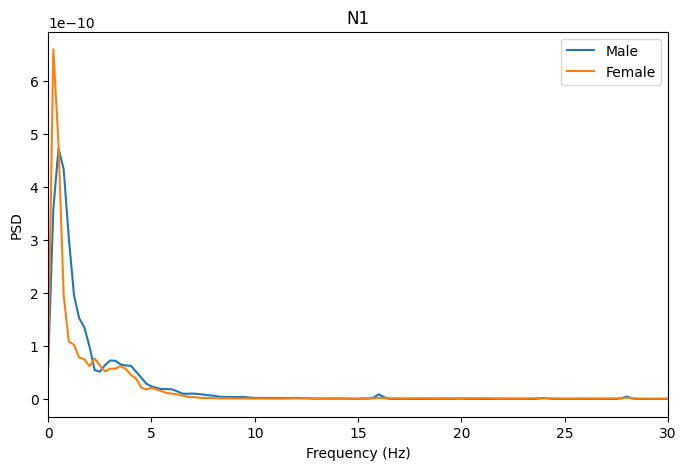

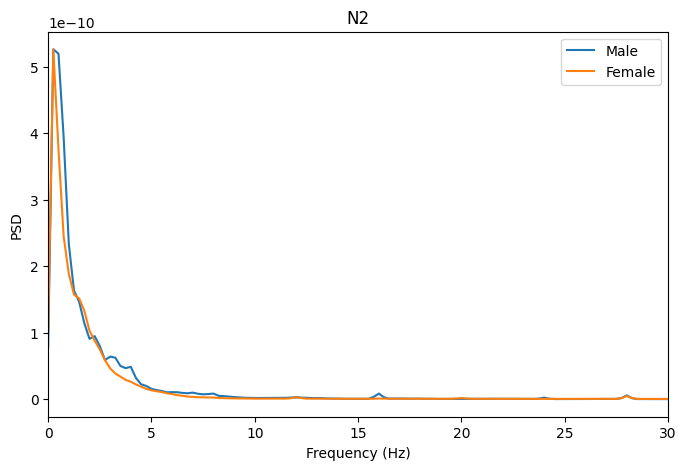

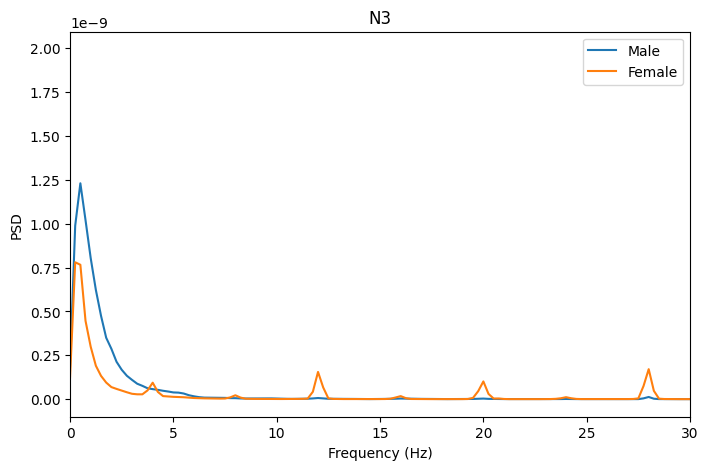

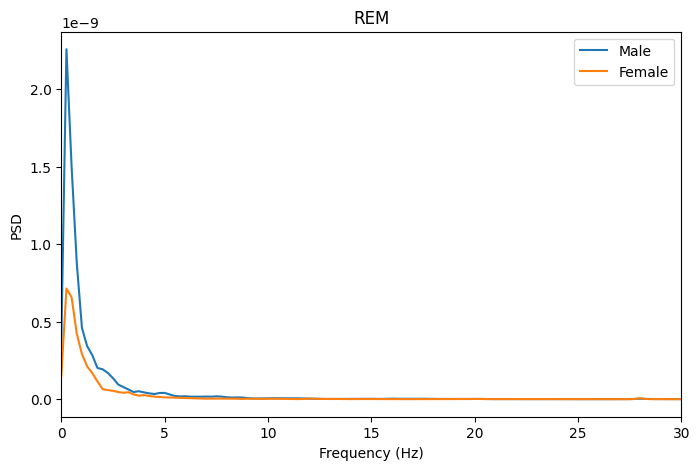

In [ ]:
stages = ["N1","N2","N3","REM"]

for stage in stages:

    male = male_data[stage]
    female = female_data[stage]

    if len(male)==0 or len(female)==0:
        continue

    f, male_psd = mean_psd(male)
    _, female_psd = mean_psd(female)

    plt.figure(figsize=(8,5))

    plt.plot(f, male_psd, label="Male")
    plt.plot(f, female_psd, label="Female")

    plt.xlim(0,30)

    plt.title(stage)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD")

    plt.legend()

    plt.show()

In [ ]:
from scipy.signal import welch
import numpy as np

def bandpower(data, fs=256):

    bands = {
        "Delta": (0.5, 4),
        "Theta": (4, 8),
        "Alpha": (8, 13),
        "Beta": (13, 30)
    }

    result = {k: [] for k in bands}

    for epoch in data:

        # 6채널 평균
        signal = epoch.mean(axis=0)

        f, pxx = welch(signal, fs=fs, nperseg=1024)

        for name, (low, high) in bands.items():

            idx = (f >= low) & (f < high)

            power = np.trapz(pxx[idx], f[idx])

            result[name].append(power)

    return result

In [ ]:
male_power = {}
female_power = {}

for stage in ["N1","N2","N3","REM"]:

    male_power[stage] = bandpower(male_data[stage])
    female_power[stage] = bandpower(female_data[stage])

/tmp/ipykernel_32634/1038647867.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  power = np.trapz(pxx[idx], f[idx])


In [ ]:
from scipy.stats import mannwhitneyu

bands = ["Delta","Theta","Alpha","Beta"]

for stage in ["N1","N2","N3","REM"]:

    print("="*50)
    print(stage)

    for band in bands:

        stat, p = mannwhitneyu(
            male_power[stage][band],
            female_power[stage][band]
        )

        print(f"{band:6s} p = {p:.4f}")

N1
Delta  p = 0.3419
Theta  p = 0.0429
Alpha  p = 0.3419
Beta   p = 0.3016
N2
Delta  p = 0.8274
Theta  p = 0.0608
Alpha  p = 0.0026
Beta   p = 0.6023
N3
Delta  p = 0.0003
Theta  p = 0.7787
Alpha  p = 0.2026
Beta   p = 0.0094
REM
Delta  p = 0.0858
Theta  p = 0.0008
Alpha  p = 0.0000
Beta   p = 0.0025


In [ ]:
import pandas as pd

# 채널별 평균 데이터
channel_df = pd.read_csv("Relative_BandPower_Channel_Comparison.csv")

# Stage × Band별 p-value 데이터
pvalue_df = pd.read_csv("Male_Female_BandPower_Comparison.csv")

# 채널 평균 계산
summary = (
    channel_df
    .groupby(["Stage", "Band"])
    .agg(
        Male_Mean=("Male Mean", "mean"),
        Female_Mean=("Female Mean", "mean"),
        Difference=("Difference", "mean")
    )
    .reset_index()
)

# 어느 성별이 더 큰지
summary["Higher"] = summary.apply(
    lambda x: "Male" if x["Male_Mean"] > x["Female_Mean"] else "Female",
    axis=1
)

# p-value 합치기
final = summary.merge(
    pvalue_df[["Stage", "Band", "P-value"]],
    on=["Stage", "Band"],
    how="left"
)

# 컬럼 순서
final = final[
    [
        "Stage",
        "Band",
        "Male_Mean",
        "Female_Mean",
        "Difference",
        "Higher",
        "P-value",
    ]
]

print(final)

# 저장
#final.to_csv("Stage_Band_Sex_Comparison.csv", index=False)

   Stage   Band  Male_Mean  Female_Mean  Difference  Higher  P-value
0     N1  Alpha     0.0331       0.0232      0.0099    Male   0.3419
1     N1   Beta     0.0593       0.0845     -0.0252  Female   0.3016
2     N1  Delta     0.7084       0.6955      0.0129    Male   0.3419
3     N1  Theta     0.1620       0.1628     -0.0008  Female   0.0429
4     N2  Alpha     0.0287       0.0216      0.0071    Male   0.0026
5     N2   Beta     0.0403       0.0461     -0.0058  Female   0.6023
6     N2  Delta     0.7705       0.8092     -0.0388  Female   0.8274
7     N2  Theta     0.1301       0.1020      0.0280    Male   0.0608
8     N3  Alpha     0.0142       0.0238     -0.0096  Female   0.2026
9     N3   Beta     0.0193       0.0453     -0.0261  Female   0.0094
10    N3  Delta     0.8860       0.8230      0.0629    Male   0.0003
11    N3  Theta     0.0674       0.0864     -0.0190  Female   0.7787
12   REM  Alpha     0.0194       0.0316     -0.0121  Female   0.0000
13   REM   Beta     0.0330       0

In [ ]:
from scipy.signal import welch
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd

# ==========================================================
# 설정
# ==========================================================

fs = 256

channels = [
    "F3",
    "F4",
    "C3",
    "C4",
    "O1",
    "O2"
]

bands = {
    "Delta": (0.5,4),
    "Theta": (4,8),
    "Alpha": (8,13),
    "Beta": (13,30)
}

# ==========================================================
# Relative Band Power
# ==========================================================

def get_relative_bandpower(data):

    result = {
        ch: {band: [] for band in bands}
        for ch in channels
    }

    for epoch in data:

        # epoch : (6,7680)

        for ch_idx, ch in enumerate(channels):

            signal = epoch[ch_idx]

            f, pxx = welch(
                signal,
                fs=fs,
                nperseg=1024
            )

            total_idx = (f >= 0.5) & (f <= 30)
            total_power = np.trapezoid(
                pxx[total_idx],
                f[total_idx]
            )

            if total_power == 0:
                continue

            for band, (low, high) in bands.items():

                idx = (f >= low) & (f < high)

                band_power = np.trapezoid(
                    pxx[idx],
                    f[idx]
                )

                relative_power = band_power / total_power

                result[ch][band].append(relative_power)

    return result

# ==========================================================
# 계산
# ==========================================================

results = []

for stage in ["N1","N2","N3","REM"]:

    if len(male_data[stage]) == 0 or len(female_data[stage]) == 0:
        continue

    male_bp = get_relative_bandpower(male_data[stage])
    female_bp = get_relative_bandpower(female_data[stage])

    for ch in channels:

        for band in bands:

            male_values = male_bp[ch][band]
            female_values = female_bp[ch][band]

            if len(male_values)==0 or len(female_values)==0:
                continue

            stat,p = mannwhitneyu(
                male_values,
                female_values,
                alternative="two-sided"
            )

            results.append({

                "Stage":stage,
                "Channel":ch,
                "Band":band,

                "Male Mean":np.mean(male_values),
                "Female Mean":np.mean(female_values),

                "Difference":
                    np.mean(male_values)
                    - np.mean(female_values),

                "P-value":p
            })

# ==========================================================
# 결과
# ==========================================================

result_df = pd.DataFrame(results)

pd.set_option("display.float_format","{:.4f}".format)

display(result_df)

result_df.to_csv(
    "Relative_BandPower_Channel_Comparison.csv",
    index=False
)

print("저장 완료")

,Stage,Channel,Band,Male Mean,Female Mean,Difference,P-value
0,N1,F3,Delta,0.6495,0.7047,-0.0552,0.4324
1,N1,F3,Theta,0.2112,0.1483,0.0628,0.0117
2,N1,F3,Alpha,0.0359,0.0220,0.0139,0.2645
3,N1,F3,Beta,0.0566,0.0856,-0.0291,0.3016
4,N1,F4,Delta,0.7284,0.6297,0.0987,0.1727
...,...,...,...,...,...,...,...
91,REM,O1,Beta,0.0281,0.0458,-0.0177,0.0000
92,REM,O2,Delta,0.8612,0.8171,0.0441,0.0000
93,REM,O2,Theta,0.0692,0.0880,-0.0189,0.0000
94,REM,O2,Alpha,0.0174,0.0300,-0.0125,0.0000


저장 완료


In [ ]:
import pandas as pd

# 채널별 결과(csv)
channel_df = pd.read_csv("Relative_BandPower_Channel_Comparison.csv")

# Stage + Band별 평균 계산
summary = (
    channel_df
    .groupby(["Stage", "Band"])
    .agg(
        Male_Mean=("Male Mean", "mean"),
        Female_Mean=("Female Mean", "mean"),
        Difference=("Difference", "mean")
    )
    .reset_index()
)

# 어느 성별이 더 큰지
summary["Higher"] = summary.apply(
    lambda x: "Male" if x["Male_Mean"] > x["Female_Mean"] else "Female",
    axis=1
)

# p-value가 있는 표
# (예: Stage_Band_Pvalue.csv를 읽었거나 이미 pvalue_df가 존재)
# pvalue_df = pd.read_csv("Stage_Band_Pvalue.csv")

# 합치기
final = summary.merge(
    pvalue_df[["Stage", "Band", "P-value"]],
    on=["Stage", "Band"],
    how="left"
)

# 보기 좋게 컬럼 순서 변경
final = final[
    [
        "Stage",
        "Band",
        "Male_Mean",
        "Female_Mean",
        "Difference",
        "Higher",
        "P-value",
    ]
]

# 소수점 자리수
pd.set_option("display.float_format", "{:.6f}".format)

print(final)

# 저장
final.to_csv("Stage_Band_Sex_Comparison.csv", index=False)

   Stage   Band  Male_Mean  Female_Mean  Difference  Higher  P-value
0     N1  Alpha   0.033084     0.023197    0.009887    Male 0.341901
1     N1   Beta   0.059264     0.084498   -0.025234  Female 0.301576
2     N1  Delta   0.708402     0.695518    0.012884    Male 0.341901
3     N1  Theta   0.161981     0.162754   -0.000773  Female 0.042888
4     N2  Alpha   0.028658     0.021583    0.007076    Male 0.002593
5     N2   Beta   0.040250     0.046082   -0.005832  Female 0.602311
6     N2  Delta   0.770454     0.809213   -0.038759  Female 0.827443
7     N2  Theta   0.130063     0.102039    0.028024    Male 0.060842
8     N3  Alpha   0.014182     0.023802   -0.009620  Female 0.202565
9     N3   Beta   0.019259     0.045319   -0.026060  Female 0.009434
10    N3  Delta   0.885955     0.823042    0.062913    Male 0.000282
11    N3  Theta   0.067417     0.086432   -0.019015  Female 0.778675
12   REM  Alpha   0.019426     0.031556   -0.012129  Female 0.000000
13   REM   Beta   0.033000     0.0

In [ ]:
sig = result_df[result_df["P-value"] < 0.05].copy()

sig = sig.sort_values("P-value")

print(sig)

   Stage Channel   Band  Male Mean  Female Mean  Difference  P-value
54    N3      F4  Alpha     0.0135       0.0265     -0.0130   0.0000
50    N3      F3  Alpha     0.0135       0.0489     -0.0354   0.0000
48    N3      F3  Delta     0.8842       0.6747      0.2094   0.0000
55    N3      F4   Beta     0.0233       0.0591     -0.0358   0.0000
52    N3      F4  Delta     0.8783       0.8097      0.0686   0.0000
46    N2      O2  Alpha     0.0262       0.0150      0.0113   0.0000
51    N3      F3   Beta     0.0202       0.1407     -0.1205   0.0000
25    N2      F3  Theta     0.1796       0.1038      0.0758   0.0000
38    N2      C4  Alpha     0.0314       0.0200      0.0114   0.0000
42    N2      O1  Alpha     0.0302       0.0191      0.0111   0.0000
76   REM      F4  Delta     0.8363       0.8073      0.0290   0.0000
71    N3      O2   Beta     0.0126       0.0190     -0.0064   0.0000
24    N2      F3  Delta     0.7021       0.7959     -0.0938   0.0001
59    N3      C3   Beta     0.0203

In [ ]:
sig = (
    result_df[result_df["P-value"] < 0.05]
    [["Stage", "Channel", "Band",
      "Male Mean", "Female Mean",
      "Difference", "P-value"]]
    .sort_values("P-value")
)

print(sig.to_string(index=False))

Stage Channel  Band  Male Mean  Female Mean  Difference  P-value
   N3      F4 Alpha     0.0135       0.0265     -0.0130   0.0000
   N3      F3 Alpha     0.0135       0.0489     -0.0354   0.0000
   N3      F3 Delta     0.8842       0.6747      0.2094   0.0000
   N3      F4  Beta     0.0233       0.0591     -0.0358   0.0000
   N3      F4 Delta     0.8783       0.8097      0.0686   0.0000
   N2      O2 Alpha     0.0262       0.0150      0.0113   0.0000
   N3      F3  Beta     0.0202       0.1407     -0.1205   0.0000
   N2      F3 Theta     0.1796       0.1038      0.0758   0.0000
   N2      C4 Alpha     0.0314       0.0200      0.0114   0.0000
   N2      O1 Alpha     0.0302       0.0191      0.0111   0.0000
  REM      F4 Delta     0.8363       0.8073      0.0290   0.0000
   N3      O2  Beta     0.0126       0.0190     -0.0064   0.0000
   N2      F3 Delta     0.7021       0.7959     -0.0938   0.0001
   N3      C3  Beta     0.0203       0.0284     -0.0080   0.0001
   N2      O1 Theta     0

중증질환 개수별로 차이가 있는지 확인

In [ ]:
import pandas as pd

# ==========================================================
# Positive 환자만 선택
# ==========================================================

positive_patients = positive_subject["patient"].unique()

patient_info = patient_meta[
    patient_meta["patient"].isin(positive_patients)
].copy()

# ==========================================================
# 중증질환 키워드
# ==========================================================

keywords = [
    "down syndrome",
    "trisomy",
    "epile",
    "seizure",
    "cerebral palsy",
    "neuromuscular",
    "muscular dystrophy",
    "spinal muscular",
    "congenital heart",
    "tetralogy",
    "hypoplastic",
    "transposition",
    "pulmonary hypertension",
    "respiratory failure",
    "tracheostomy",
    "ventilator",
    "bronchopulmonary dysplasia",
    "bpd",
    "prematurity",
    "premature",
    "prader",
    "pierre robin",
    "micrognathia",
    "craniofacial",
    "hydrocephalus",
    "myelomeningocele",
    "spina bifida",
    "achondroplasia"
]

# ==========================================================
# 중증질환 검색
# ==========================================================

diag = diag_df.copy()

diag["DX_NAME"] = diag["DX_NAME"].fillna("").str.lower()

pattern = "|".join(keywords)

severe = diag[
    diag["DX_NAME"].str.contains(pattern, regex=True)
].copy()

# ==========================================================
# 환자별 중증질환 목록 (중복 제거)
# ==========================================================

severe_name = (
    severe.groupby("STUDY_PAT_ID")["DX_NAME"]
    .unique()
    .reset_index(name="SEVERE_DISEASES")
)

severe_name["NUM_SEVERE_DX"] = (
    severe_name["SEVERE_DISEASES"].apply(len)
)

# ==========================================================
# Positive 환자와 merge
# ==========================================================

result = patient_info.merge(
    severe_name,
    on="STUDY_PAT_ID",
    how="left"
)

result["NUM_SEVERE_DX"] = (
    result["NUM_SEVERE_DX"]
    .fillna(0)
    .astype(int)
)

# result["SEVERE_DISEASES"] = (
#     result["SEVERE_DISEASES"]
#     .apply(lambda x: x if isinstance(x, (list, tuple)) else [])
# )

# ==========================================================
# 중증질환 많은 순
# ==========================================================

result = result.sort_values(
    "NUM_SEVERE_DX",
    ascending=False
)

print(
    result[
        [
            "patient",
            "STUDY_PAT_ID",
            "GENDER",
            "NUM_SEVERE_DX",
            "SEVERE_DISEASES"
        ]
    ]
)

        patient  STUDY_PAT_ID  GENDER  NUM_SEVERE_DX  \
38   18949_4846         18949    Male             24   
32   17623_4480         17623  Female             23   
9     4228_6760          4228    Male             18   
12   6808_13294          6808  Female             15   
1    1102_10120          1102    Male             15   
2     1498_6517          1498  Female             14   
5     1912_8209          1912  Female             13   
37   18655_7177         18655    Male             12   
8    3805_19858          3805    Male             11   
31  17617_16135         17617    Male             11   
16    8668_6322          8668    Male             11   
22   14872_2584         14872  Female             10   
41   20509_2572         20509    Male             10   
18  10996_10132         10996    Male             10   
4    1672_12538          1672    Male             10   
33  17731_24073         17731    Male             10   
21    14314_202         14314  Female           

In [ ]:
print(severe_name.head())

print(severe_name.columns)

   STUDY_PAT_ID                                    SEVERE_DISEASES  \
0             7  [seizure, localization-related epilepsy, epile...   
1            22  [prematurity, 500-749 grams, 25-26 completed w...   
2            40  [hypoplastic left heart syndrome, hlhs (hypopl...   
3            55  [tetralogy of fallot, history of tetralogy of ...   
4            91              [micrognathia, pierre robin sequence]   

   NUM_SEVERE_DX  
0             16  
1              9  
2              2  
3              5  
4              2  
Index(['STUDY_PAT_ID', 'SEVERE_DISEASES', 'NUM_SEVERE_DX'], dtype='object')


In [ ]:
import pandas as pd

# 사분위수 기준으로 4개 그룹 생성
result["CLASS"] = pd.qcut(
    result["NUM_SEVERE_DX"],
    q=4,
    labels=["Q1_Low", "Q2", "Q3", "Q4_High"],
    duplicates="drop"   # 동일한 값이 많아 분위수가 겹칠 경우 대비
)

print(result[
    [
        "patient",
        "STUDY_PAT_ID",
        "NUM_SEVERE_DX",
        "CLASS"
    ]
].sort_values("NUM_SEVERE_DX", ascending=False))

        patient  STUDY_PAT_ID  NUM_SEVERE_DX    CLASS
38   18949_4846         18949             24  Q4_High
32   17623_4480         17623             23  Q4_High
9     4228_6760          4228             18  Q4_High
12   6808_13294          6808             15  Q4_High
1    1102_10120          1102             15  Q4_High
2     1498_6517          1498             14  Q4_High
5     1912_8209          1912             13  Q4_High
37   18655_7177         18655             12  Q4_High
8    3805_19858          3805             11  Q4_High
31  17617_16135         17617             11  Q4_High
16    8668_6322          8668             11  Q4_High
22   14872_2584         14872             10       Q3
41   20509_2572         20509             10       Q3
18  10996_10132         10996             10       Q3
4    1672_12538          1672             10       Q3
33  17731_24073         17731             10       Q3
21    14314_202         14314             10       Q3
40  20023_22390         2002

In [ ]:
# 사분위수 경계 확인
print(result["NUM_SEVERE_DX"].quantile([0, 0.25, 0.5, 0.75, 1]))

0.0000    3.0000
0.2500    6.0000
0.5000    8.0000
0.7500   10.7500
1.0000   24.0000
Name: NUM_SEVERE_DX, dtype: float64


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
from scipy.signal import welch

# ==========================================================
# 설정
# ==========================================================

save_folder = "positive_patient_data"

sf = 256

bands = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta":  (13, 30),
}

stages = ["N1", "N2", "N3", "REM"]

# ==========================================================
# Stage별 반복
# ==========================================================

for stage in stages:

    print("\n" + "=" * 60)
    print(f"Stage : {stage}")
    print("=" * 60)

    results = []

    # ======================================================
    # 환자별 반복
    # ======================================================

    for npy_file in sorted(glob.glob(os.path.join(save_folder, "*.npy"))):

        patient = os.path.splitext(os.path.basename(npy_file))[0]

        eeg = np.load(npy_file)      # (epoch, channel, 7680)

        csv_file = npy_file.replace(".npy", ".csv")
        info = pd.read_csv(csv_file)

        # 해당 stage epoch만 선택
        idx = info["stage"] == stage

        if idx.sum() == 0:
            continue

        eeg = eeg[idx.values]

        feature = {"patient": patient}

        abs_power = {band: [] for band in bands}
        rel_power = {band: [] for band in bands}

        for epoch in eeg:

            for ch in epoch:

                freqs, psd = welch(
                    ch,
                    fs=sf,
                    nperseg=1024
                )

                total_idx = (freqs >= 0.5) & (freqs < 30)

                total_power = np.trapezoid(
                    psd[total_idx],
                    freqs[total_idx]
                )

                if total_power == 0:
                    continue

                for band, (low, high) in bands.items():

                    band_idx = (freqs >= low) & (freqs < high)

                    power = np.trapezoid(
                        psd[band_idx],
                        freqs[band_idx]
                    )

                    abs_power[band].append(power)
                    rel_power[band].append(power / total_power)

        # 환자 평균
        for band in bands:

            feature[f"{band}_abs"] = np.mean(abs_power[band])
            feature[f"{band}_rel"] = np.mean(rel_power[band])

        results.append(feature)

    # ======================================================
    # DataFrame
    # ======================================================

    bandpower_df = pd.DataFrame(results)

    bandpower_df = bandpower_df.merge(
        result[["patient", "CLASS", "NUM_SEVERE_DX"]],
        on="patient",
        how="left"
    )

    print(f"\nPatients : {len(bandpower_df)}")

    # ======================================================
    # Spearman
    # ======================================================

    from scipy.stats import spearmanr

    for band in ["Delta_rel", "Theta_rel", "Alpha_rel", "Beta_rel"]:

        rho, p = spearmanr(
            bandpower_df["NUM_SEVERE_DX"],
            bandpower_df[band]
        )

        print(f"{band:10s}  rho={rho:.3f}   p={p:.4f}")


Stage : N1

Patients : 6
Delta_rel   rho=-0.928   p=0.0077
Theta_rel   rho=0.493   p=0.3206
Alpha_rel   rho=0.841   p=0.0361
Beta_rel    rho=0.899   p=0.0149

Stage : N2

Patients : 27
Delta_rel   rho=-0.149   p=0.4571
Theta_rel   rho=0.130   p=0.5171
Alpha_rel   rho=0.018   p=0.9285
Beta_rel    rho=0.130   p=0.5171

Stage : N3

Patients : 24
Delta_rel   rho=-0.079   p=0.7148
Theta_rel   rho=0.300   p=0.1546
Alpha_rel   rho=-0.074   p=0.7316
Beta_rel    rho=-0.202   p=0.3440

Stage : REM

Patients : 35
Delta_rel   rho=-0.197   p=0.2575
Theta_rel   rho=0.129   p=0.4597
Alpha_rel   rho=0.232   p=0.1791
Beta_rel    rho=0.178   p=0.3060


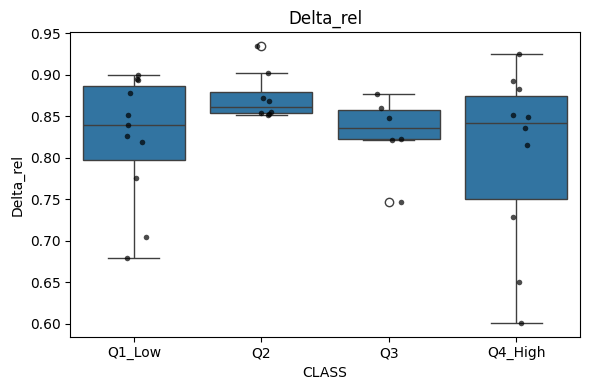

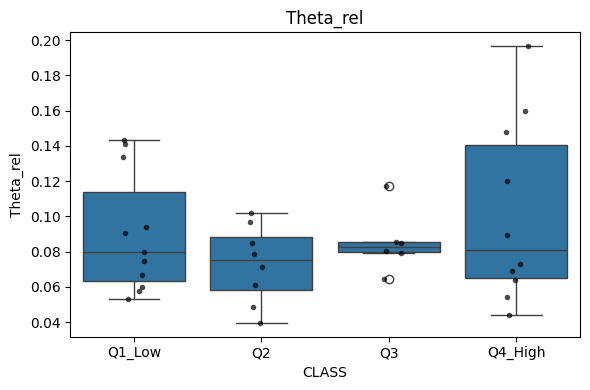

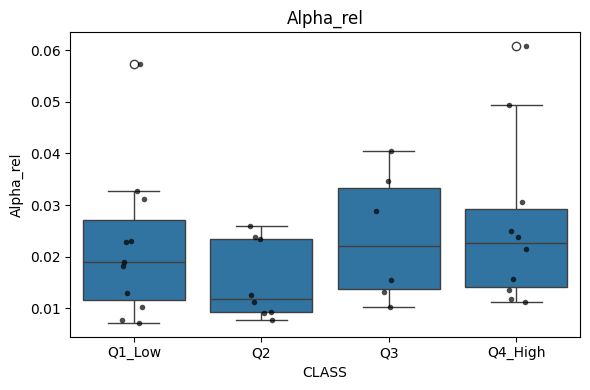

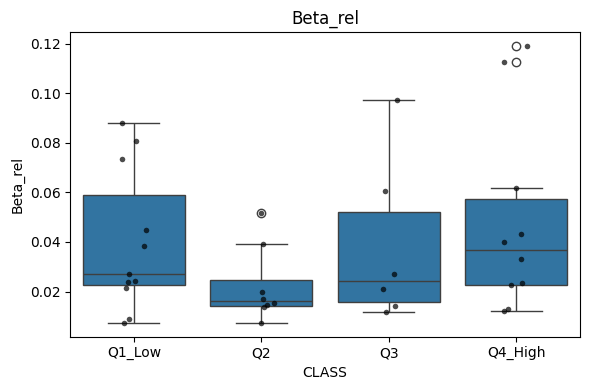

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

bands = ["Delta_rel", "Theta_rel", "Alpha_rel", "Beta_rel"]

order = ["Q1_Low", "Q2", "Q3", "Q4_High"]

for band in bands:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=bandpower_df,
        x="CLASS",
        y=band,
        order=order
    )

    sns.stripplot(
        data=bandpower_df,
        x="CLASS",
        y=band,
        order=order,
        color="black",
        size=4,
        alpha=0.7
    )

    plt.title(band)
    plt.tight_layout()
    plt.show()

Kruskal-Wallis

In [ ]:
from scipy.stats import kruskal

bands = ["Delta_rel", "Theta_rel", "Alpha_rel", "Beta_rel"]

order = ["Q1_Low", "Q2", "Q3", "Q4_High"]

for band in bands:

    groups = []

    for c in order:
        groups.append(
            bandpower_df.loc[
                bandpower_df["CLASS"] == c,
                band
            ].dropna()
        )

    H, p = kruskal(*groups)

    print(f"{band}")
    print(f"H = {H:.3f}")
    print(f"p = {p:.4f}")
    print("-"*40)

Delta_rel
H = 4.503
p = 0.2120
----------------------------------------
Theta_rel
H = 1.368
p = 0.7130
----------------------------------------
Alpha_rel
H = 3.425
p = 0.3306
----------------------------------------
Beta_rel
H = 3.259
p = 0.3533
----------------------------------------


In [ ]:
pip install scikit_posthocs

In [ ]:
import scikit_posthocs as sp

posthoc = sp.posthoc_dunn(
    bandpower_df,
    val_col="Delta_rel",
    group_col="CLASS",
    p_adjust="bonferroni"
)

print(posthoc)

         Q1_Low     Q2     Q3  Q4_High
Q1_Low   1.0000 0.6557 1.0000   1.0000
Q2       0.6557 1.0000 0.5246   0.3628
Q3       1.0000 0.5246 1.0000   1.0000
Q4_High  1.0000 0.3628 1.0000   1.0000


중증질환의 개수와 eeg 사이의 상관관계는 없었음(relative power 차이가 없음)





Spearman Correlation

∣ρ∣<0.3 → 약한 상관

    0.3∼0.5 → 중간 정도 상관
>0.5 → 강한 상관

In [ ]:
from scipy.stats import spearmanr

for band in ["Delta_rel", "Theta_rel", "Alpha_rel", "Beta_rel"]:

    rho, p = spearmanr(
        bandpower_df["NUM_SEVERE_DX"],
        bandpower_df[band]
    )

    print(f"{band}")
    print(f"rho = {rho:.3f}, p = {p:.4f}")
    print()

Delta_rel
rho = -0.197, p = 0.2575

Theta_rel
rho = 0.129, p = 0.4597

Alpha_rel
rho = 0.232, p = 0.1791

Beta_rel
rho = 0.178, p = 0.3060



채널별 band power 분석 (F3, F4, C3, C4, O1, O2를 따로 계산)

각 채널에서 EEG feature가 중증도(NUM_SEVERE_DX)와 관련이 있는지 계산
(ex. 중증 진단 개수가 많아질수록 O2의 Theta relative power도 증가하는 경향이 있는지)

-> 중증질환의 개수가 높아질수록

-O2 Theta power가 증가하는 경향

-O1 Alpha power가 증가하는 경향

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
from scipy.signal import welch

save_folder = "positive_patient_data"

sf = 256

channels = [
    "F3",
    "F4",
    "C3",
    "C4",
    "O1",
    "O2"
]

bands = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta": (13, 30),
}

stages = ["N1", "N2", "N3", "REM"]

channel_df_dict = {}

for stage in stages:

    print(f"\n===== {stage} =====")

    results = []

    for npy_file in sorted(glob.glob(os.path.join(save_folder, "*.npy"))):

        patient = os.path.splitext(os.path.basename(npy_file))[0]

        eeg = np.load(npy_file)

        csv_file = npy_file.replace(".npy", ".csv")
        info = pd.read_csv(csv_file)

        idx = info["stage"] == stage

        if idx.sum() == 0:
            continue

        eeg = eeg[idx.values]

        feature = {"patient": patient}

        for ch_idx, ch_name in enumerate(channels):

            rel_power = {band: [] for band in bands}

            for epoch in eeg:

                signal = epoch[ch_idx]

                freqs, psd = welch(
                    signal,
                    fs=sf,
                    nperseg=1024
                )

                total_idx = (freqs >= 0.5) & (freqs < 30)

                total_power = np.trapezoid(
                    psd[total_idx],
                    freqs[total_idx]
                )

                if total_power == 0:
                    continue

                for band, (low, high) in bands.items():

                    band_idx = (freqs >= low) & (freqs < high)

                    power = np.trapezoid(
                        psd[band_idx],
                        freqs[band_idx]
                    )

                    rel_power[band].append(power / total_power)

            for band in bands:
                feature[f"{ch_name}_{band}_rel"] = np.mean(rel_power[band])

        results.append(feature)

    channel_df = pd.DataFrame(results)

    channel_df = channel_df.merge(
        result[["patient", "CLASS", "NUM_SEVERE_DX"]],
        on="patient",
        how="left"
    )

    channel_df_dict[stage] = channel_df

    print("Patients:", len(channel_df))

channel_df_dict["N1"].head()


===== N1 =====
Patients: 6

===== N2 =====
Patients: 27

===== N3 =====
Patients: 24

===== REM =====
Patients: 35


,patient,F3_Delta_rel,F3_Theta_rel,F3_Alpha_rel,F3_Beta_rel,F4_Delta_rel,F4_Theta_rel,F4_Alpha_rel,F4_Beta_rel,C3_Delta_rel,...,O1_Delta_rel,O1_Theta_rel,O1_Alpha_rel,O1_Beta_rel,O2_Delta_rel,O2_Theta_rel,O2_Alpha_rel,O2_Beta_rel,CLASS,NUM_SEVERE_DX
0,10996_10132,0.7333,0.1943,0.0237,0.0332,0.8811,0.0874,0.0060,0.0096,0.7227,...,0.7943,0.1537,0.0189,0.0218,0.8830,0.0862,0.0053,0.0071,Q3,10
1,1102_10120,0.5832,0.2133,0.0518,0.0914,0.7306,0.1248,0.0519,0.0640,0.6057,...,0.7171,0.1033,0.0397,0.1168,0.7685,0.0924,0.0382,0.0795,Q4_High,15
2,12304_4792,0.8596,0.0846,0.0138,0.0185,0.8582,0.0923,0.0132,0.0180,0.8788,...,0.8603,0.0851,0.0154,0.0215,0.8545,0.0939,0.0161,0.0222,Q1_Low,4
3,17623_4480,0.6475,0.1725,0.0251,0.1110,0.5457,0.1366,0.0432,0.2352,0.6420,...,0.5995,0.2050,0.0279,0.1343,0.7146,0.1859,0.0211,0.0429,Q4_High,23
4,17731_24073,0.7173,0.2212,0.0192,0.0154,0.6778,0.2235,0.0278,0.0438,0.6947,...,0.7999,0.1467,0.0129,0.0135,0.7735,0.1572,0.0175,0.0248,Q3,10


In [ ]:
import os

save_dir = "stage_channel_results"
os.makedirs(save_dir, exist_ok=True)

for stage, df in channel_df_dict.items():
    df.to_csv(
        os.path.join(save_dir, f"channel_df_{stage}.csv"),
        index=False
    )

print("저장 완료!")

저장 완료!


In [ ]:
from scipy.stats import spearmanr
import pandas as pd

results = []

for stage, df in channel_df_dict.items():

    feature_cols = [c for c in df.columns if c.endswith("_rel")]

    for feature in feature_cols:

        tmp = df[[feature, "NUM_SEVERE_DX"]].dropna()

        if len(tmp) < 3:
            continue

        rho, p = spearmanr(
            tmp[feature],
            tmp["NUM_SEVERE_DX"]
        )

        results.append({
            "Stage": stage,
            "Feature": feature,
            "rho": rho,
            "p": p,
            "N": len(tmp)
        })

spearman_df = pd.DataFrame(results)

spearman_df

,Stage,Feature,rho,p,N
0,N1,F3_Delta_rel,-0.9276,0.0077,6
1,N1,F3_Theta_rel,0.1739,0.7417,6
2,N1,F3_Alpha_rel,0.7537,0.0835,6
3,N1,F3_Beta_rel,0.8117,0.0499,6
4,N1,F4_Delta_rel,-0.6957,0.1248,6
...,...,...,...,...,...
91,REM,O1_Beta_rel,0.2076,0.2313,35
92,REM,O2_Delta_rel,-0.2442,0.1574,35
93,REM,O2_Theta_rel,0.2271,0.1896,35
94,REM,O2_Alpha_rel,0.2320,0.1799,35


In [ ]:
import os

save_dir = "spearman_results"
os.makedirs(save_dir, exist_ok=True)

spearman_df.to_csv(
    os.path.join(save_dir, "spearman_stage_channel.csv"),
    index=False
)

print("저장 완료!")

저장 완료!


FDR(Benjamini-Hochberg) 보정
유의하다고 나온 결과들 중에서 거짓 양성(False Positive)의 비율을 조절

In [ ]:
pip install statsmodels

In [ ]:
from statsmodels.stats.multitest import multipletests

# FDR(Benjamini-Hochberg) 보정
reject, qvals, _, _ = multipletests(
    spearman_df["p"],
    alpha=0.05,
    method="fdr_bh"
)

spearman_df["q"] = qvals
spearman_df["Significant_FDR"] = reject

# q-value 기준으로 정렬
spearman_df = spearman_df.sort_values("q")

spearman_df.head(30)

,Stage,Feature,rho,p,N,q,Significant_FDR
0,N1,F3_Delta_rel,-0.9276,0.0077,6,0.3680,False
16,N1,O1_Delta_rel,-0.9276,0.0077,6,0.3680,False
11,N1,C3_Beta_rel,0.8407,0.0361,6,0.4327,False
8,N1,C3_Delta_rel,-0.8407,0.0361,6,0.4327,False
20,N1,O2_Delta_rel,-0.8407,0.0361,6,0.4327,False
19,N1,O1_Beta_rel,0.8986,0.0149,6,0.4327,False
18,N1,O1_Alpha_rel,0.8407,0.0361,6,0.4327,False
23,N1,O2_Beta_rel,0.8407,0.0361,6,0.4327,False
7,N1,F4_Beta_rel,0.8117,0.0499,6,0.4351,False
3,N1,F3_Beta_rel,0.8117,0.0499,6,0.4351,False


stage별로 FDR 진행
-> 전체 FDR에서는 통과한 애가 없음

In [ ]:
from statsmodels.stats.multitest import multipletests
import pandas as pd

# 기존 결과 복사
spearman_stage_fdr = spearman_df.copy()

# q-value와 유의성 컬럼 생성
spearman_stage_fdr["q"] = None
spearman_stage_fdr["Significant_FDR"] = False

# Stage별 FDR
for stage in spearman_stage_fdr["Stage"].unique():

    idx = spearman_stage_fdr["Stage"] == stage

    pvals = spearman_stage_fdr.loc[idx, "p"]

    reject, qvals, _, _ = multipletests(
        pvals,
        alpha=0.05,
        method="fdr_bh"
    )

    spearman_stage_fdr.loc[idx, "q"] = qvals
    spearman_stage_fdr.loc[idx, "Significant_FDR"] = reject

# q-value 기준 정렬
spearman_stage_fdr = spearman_stage_fdr.sort_values(
    ["Stage", "q", "p"]
)

spearman_stage_fdr

,Stage,Feature,rho,p,N,q,Significant_FDR
0,N1,F3_Delta_rel,-0.9276,0.0077,6,0.0920,False
16,N1,O1_Delta_rel,-0.9276,0.0077,6,0.0920,False
19,N1,O1_Beta_rel,0.8986,0.0149,6,0.1082,False
11,N1,C3_Beta_rel,0.8407,0.0361,6,0.1082,False
8,N1,C3_Delta_rel,-0.8407,0.0361,6,0.1082,False
...,...,...,...,...,...,...,...
84,REM,C4_Delta_rel,-0.0912,0.6025,35,0.7230,False
86,REM,C4_Alpha_rel,0.0546,0.7555,35,0.8315,False
76,REM,F4_Delta_rel,-0.0530,0.7622,35,0.8315,False
87,REM,C4_Beta_rel,0.0421,0.8104,35,0.8456,False


In [ ]:
import os

save_dir = "spearman_results"
os.makedirs(save_dir, exist_ok=True)

spearman_stage_fdr.to_csv(
    os.path.join(save_dir, "spearman_stagewise_FDR.csv"),
    index=False
)

print("저장 완료!")

저장 완료!


In [ ]:
sig = spearman_stage_fdr[
    spearman_stage_fdr["Significant_FDR"]
]

print(sig)

Empty DataFrame
Columns: [Stage, Feature, rho, p, N, q, Significant_FDR]
Index: []


In [ ]:
import os

save_dir = "spearman_results"
os.makedirs(save_dir, exist_ok=True)

spearman_df.to_csv(
    os.path.join(save_dir, "spearman_stage_channel_FDR.csv"),
    index=False
)

print("저장 완료!")

저장 완료!


STOP

B. Signal Preprocessing


B-1~B-4 1개의 signal 전처리
B-5 negative 전처리
B-6 positive 전처리

Sample : Positive EEG
Raw EEG shape      : (6, 7680)
Filtered EEG shape : (6, 7680)


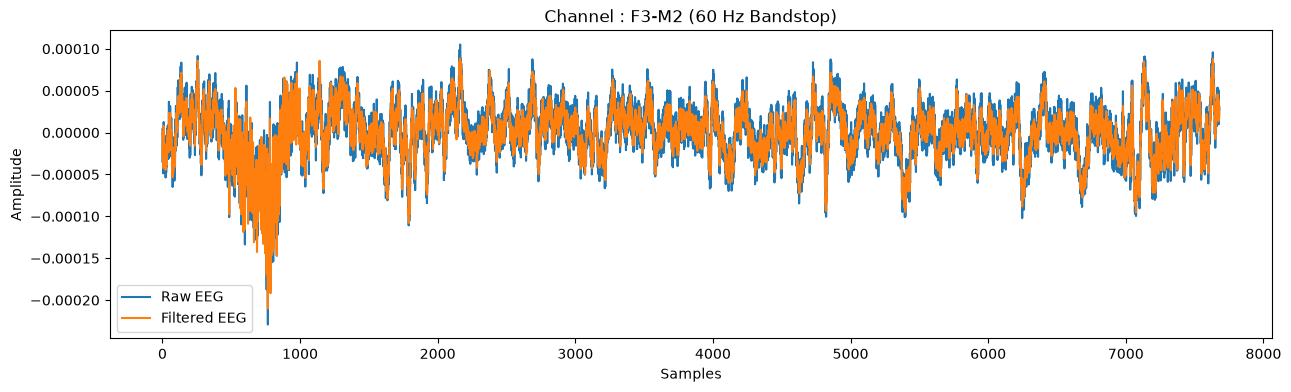

In [ ]:
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# B-1. 60 Hz Butterworth Bandstop Filter (예시 확인)
# ==========================================================

# Positive가 있으면 Positive 사용
if len(X) > 0:
    sample_epoch = X[0].copy()
    print("Sample : Positive EEG")

# 없으면 Negative 사용
else:
    sample_epoch = X_neg[0].copy()
    print("Sample : Negative EEG")

SFREQ = 256

# 60 Hz Bandstop
b, a = butter(
    N=3,
    Wn=[59, 61],
    btype="bandstop",
    fs=SFREQ
)

filtered_epoch = np.zeros_like(sample_epoch)

for ch in range(sample_epoch.shape[0]):

    filtered_epoch[ch] = filtfilt(
        b,
        a,
        sample_epoch[ch]
    )

print("Raw EEG shape      :", sample_epoch.shape)
print("Filtered EEG shape :", filtered_epoch.shape)

plt.figure(figsize=(15,4))

plt.plot(sample_epoch[0], label="Raw EEG")
plt.plot(filtered_epoch[0], label="Filtered EEG")

plt.title("Channel : F3-M2 (60 Hz Bandstop)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.legend()
plt.show()

After 60 Hz Filter : (6, 7680)
After 120 Hz Filter: (6, 7680)


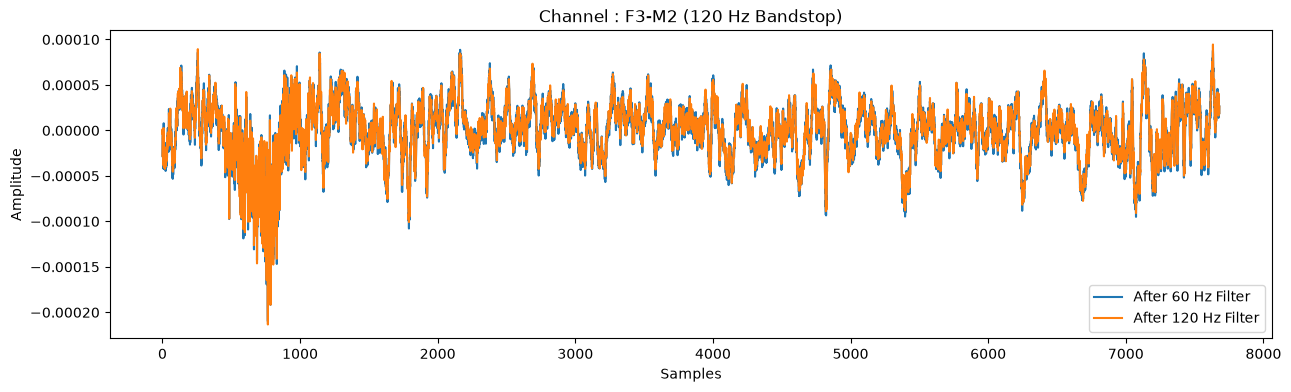

In [ ]:
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# B-2. 120 Hz Butterworth Bandstop Filter (예시 확인)
# ==========================================================

# B-1에서 생성한 60 Hz 제거된 EEG 사용
sample_epoch = filtered_epoch.copy()

SFREQ = 256

# 120 Hz Butterworth Bandstop Filter
b, a = butter(
    N=3,
    Wn=[119, 121],
    btype="bandstop",
    fs=SFREQ
)

filtered_epoch_120 = np.zeros_like(sample_epoch)

for ch in range(sample_epoch.shape[0]):

    filtered_epoch_120[ch] = filtfilt(
        b,
        a,
        sample_epoch[ch]
    )

print("After 60 Hz Filter :", sample_epoch.shape)
print("After 120 Hz Filter:", filtered_epoch_120.shape)

# ==========================================================
# Filter 결과 비교
# ==========================================================

plt.figure(figsize=(15,4))

plt.plot(sample_epoch[0], label="After 60 Hz Filter")
plt.plot(filtered_epoch_120[0], label="After 120 Hz Filter")

plt.title("Channel : F3-M2 (120 Hz Bandstop)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.legend()

plt.show()

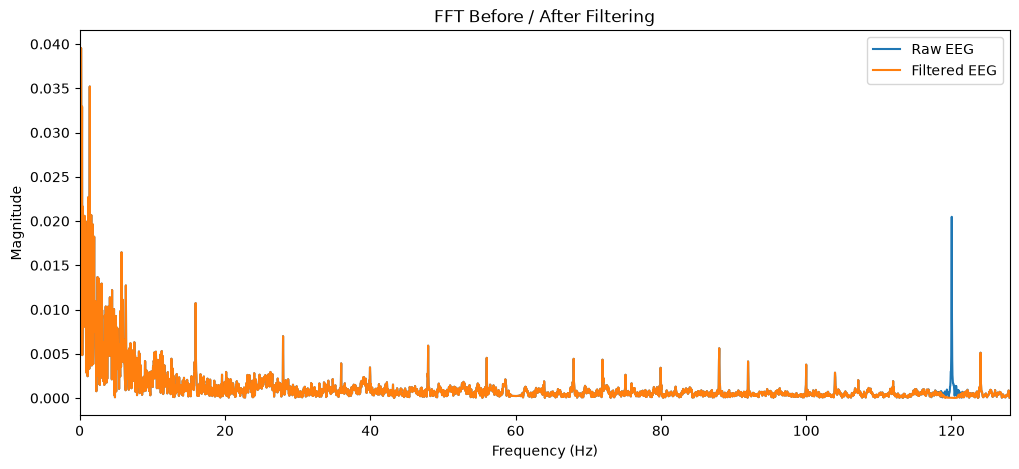

In [ ]:
#FFT로 필터 부분이 줄어들었는지 확인

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FFT 비교 (Filter 전후)
# ==========================================================

fs = 256

raw_signal = sample_epoch[0]
filtered_signal = filtered_epoch_120[0]

freq = np.fft.rfftfreq(len(raw_signal), d=1/fs)

raw_fft = np.abs(np.fft.rfft(raw_signal))
filtered_fft = np.abs(np.fft.rfft(filtered_signal))

plt.figure(figsize=(12,5))

plt.plot(freq, raw_fft, label="Raw EEG")

plt.plot(freq, filtered_fft, label="Filtered EEG")

plt.xlim(0,128)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.title("FFT Before / After Filtering")

plt.legend()

plt.show()

Hann window
STFT를 할 때 데이터를 잘라주는 창(window)의 한 종류
시작과 끝은 0이고 가운데가 가장 큰 신호라서 창의 시작과 끝이 부드럽게 연결될 수 있도록 함
구간의 경계에 생기는 왜곡을 줄이기 위해 사용됨

Frequency bins : 129
Time bins      : 61
STFT shape     : (129, 61)


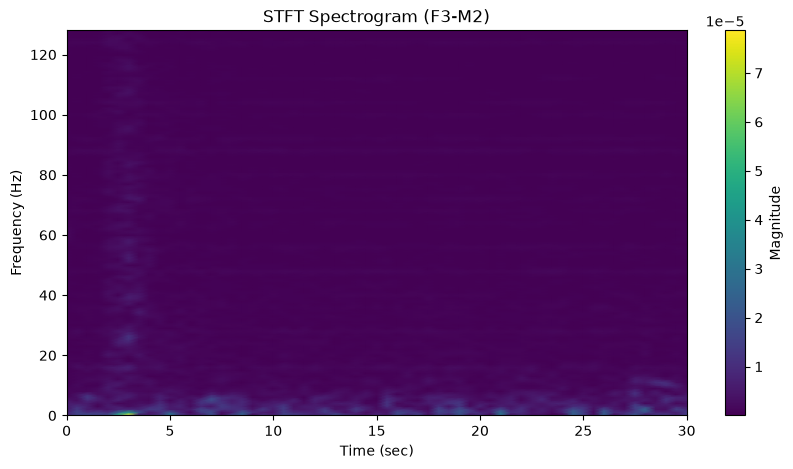

In [ ]:
from scipy.signal import stft
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# B-4. STFT (예시 확인)
# ==========================================================

# 120 Hz까지 필터링된 EEG 사용
sample_epoch = filtered_epoch_120.copy()

SFREQ = 256

# 논문과 동일한 파라미터
NPERSEG = 256
NOVERLAP = 128

# 첫 번째 채널(F3-M2)
f, t, Zxx = stft(
    sample_epoch[0],
    fs=SFREQ,
    window="hann",
    nperseg=NPERSEG,
    noverlap=NOVERLAP
)

print("Frequency bins :", len(f))
print("Time bins      :", len(t))
print("STFT shape     :", np.abs(Zxx).shape)

# ==========================================================
# Spectrogram
# ==========================================================

plt.figure(figsize=(10,5))

plt.pcolormesh(
    t,
    f,
    np.abs(Zxx),
    shading="gouraud"
)

plt.xlabel("Time (sec)")
plt.ylabel("Frequency (Hz)")
plt.title("STFT Spectrogram (F3-M2)")
plt.colorbar(label="Magnitude")

plt.show()

# Negative, Positive EEG 를 이용하여 STFT 진행


In [ ]:
from scipy.signal import butter, filtfilt, stft
import numpy as np

# ==========================================================
# B-5. Negative EEG -> STFT
# ==========================================================

SFREQ = 256

b60, a60 = butter(
    3,
    [59, 61],
    btype="bandstop",
    fs=SFREQ
)

b120, a120 = butter(
    3,
    [119, 121],
    btype="bandstop",
    fs=SFREQ
)

NPERSEG = 256
NOVERLAP = 128

X_neg_stft = []

for epoch in X_neg:

    channel_result = []

    for ch in epoch:

        # 60 Hz 제거
        ch = filtfilt(b60, a60, ch)

        # 120 Hz 제거
        ch = filtfilt(b120, a120, ch)

        # STFT
        _, _, Zxx = stft(
            ch,
            fs=SFREQ,
            window="hann",
            nperseg=NPERSEG,
            noverlap=NOVERLAP
        )

        channel_result.append(np.abs(Zxx))

    X_neg_stft.append(channel_result)

X_neg_stft = np.array(X_neg_stft)

print("Negative STFT shape :", X_neg_stft.shape)

# ==========================================================
# Stage별 STFT 개수 확인
# ==========================================================

stage_counts = (
    meta_neg["stage"]
    .value_counts()
    .reindex(["N1","N2","N3","REM"], fill_value=0)
)

print()
print("Negative STFT (Stage별)")
print(stage_counts)

Negative STFT shape : (2427, 6, 129, 61)

Negative STFT (Stage별)
stage
N1      108
N2      714
N3     1358
REM     247
Name: count, dtype: int64


In [ ]:
from scipy.signal import butter, filtfilt, stft
import numpy as np

# ==========================================================
# Positive EEG -> STFT
# ==========================================================

SFREQ = 256

# Butterworth Bandstop Filter
b60, a60 = butter(
    3,
    [59, 61],
    btype="bandstop",
    fs=SFREQ
)

b120, a120 = butter(
    3,
    [119, 121],
    btype="bandstop",
    fs=SFREQ
)

NPERSEG = 256
NOVERLAP = 128

X_stft = []

for epoch in X:

    channel_result = []

    for ch in epoch:

        # 60 Hz 제거
        ch = filtfilt(b60, a60, ch)

        # 120 Hz 제거
        ch = filtfilt(b120, a120, ch)

        # STFT
        _, _, Zxx = stft(
            ch,
            fs=SFREQ,
            window="hann",
            nperseg=NPERSEG,
            noverlap=NOVERLAP
        )

        channel_result.append(np.abs(Zxx))

    X_stft.append(channel_result)

X_stft = np.array(X_stft)

print("Positive STFT shape :", X_stft.shape)

print()

stage_counts = (
    meta["stage"]
    .value_counts()
    .reindex(["N1", "N2", "N3", "REM"], fill_value=0)
)

print("Positive STFT (Stage별)")
print(stage_counts)

Positive STFT shape : (2, 6, 129, 61)

Positive STFT (Stage별)
stage
N1     0
N2     2
N3     0
REM    0
Name: count, dtype: int64


# 논문 C 부분
age, gender 매칭

In [ ]:
import pandas as pd
import numpy as np

# ==========================================================
# Read Metadata
# ==========================================================

demographic = pd.read_csv(
    r"D:/physionet.org/files/nch-sleep/3.1.0/Health_Data/DEMOGRAPHIC.csv"
)

sleep_study = pd.read_csv(
    r"D:/physionet.org/files/nch-sleep/3.1.0/Health_Data/SLEEP_STUDY.csv"
)

# ==========================================================
# Merge
# ==========================================================

subject_info = demographic.merge(

    sleep_study[
        [
            "STUDY_PAT_ID",
            "SLEEP_STUDY_ID",
            "AGE_AT_SLEEP_STUDY_DAYS"
        ]
    ],

    on="STUDY_PAT_ID",

    how="inner"

)

# EDF filename과 동일한 key 생성
subject_info["patient"] = (
    subject_info["STUDY_PAT_ID"].astype(str)
    + "_"
    + subject_info["SLEEP_STUDY_ID"].astype(str)
)

# Age
subject_info["age"] = (
    subject_info["AGE_AT_SLEEP_STUDY_DAYS"] / 365.25
)

# Gender
subject_info["gender"] = subject_info["GENDER_DESCR"]

# ==========================================================
# Age Group
# ==========================================================

def age_group(age):

    if age < 2:
        return "0-2"

    elif age < 5:
        return "2-5"

    elif age < 8:
        return "5-8"

    elif age < 12:
        return "8-12"

    else:
        return "12-18"

subject_info["age_group"] = subject_info["age"].apply(age_group)

subject_info["group"] = (
    subject_info["age_group"]
    + "_"
    + subject_info["gender"]
)

print(subject_info[
    [
        "patient",
        "age",
        "gender",
        "age_group",
        "group"
    ]
].head())

    patient        age  gender age_group         group
0    1_4789   9.138946    Male      8-12     8-12_Male
1   7_12595   2.121834  Female       2-5    2-5_Female
2  10_22339  13.092402  Female     12-18  12-18_Female
3  16_24241  12.068446    Male     12-18    12-18_Male
4  22_23233   4.736482    Male       2-5      2-5_Male


In [ ]:
# Positive metadata에 Age/Gender 붙이기
meta = meta.merge(
    subject_info[
        [
            "patient",
            "age",
            "gender",
            "age_group",
            "group"
        ]
    ],
    on="patient",
    how="left"
)

# Negative metadata에 Age/Gender 붙이기
meta_neg = meta_neg.merge(
    subject_info[
        [
            "patient",
            "age",
            "gender",
            "age_group",
            "group"
        ]
    ],
    on="patient",
    how="left"
)

In [ ]:
print(meta.head())

print()

print(meta_neg.head())

       patient stage  sleep_epoch_start  desaturation_onset  duration  \
0  10000_17728    N2        8850.960938         8858.363281      16.0   
1  10003_26038    N2       15390.367188        15411.148438      53.0   

    min_spo2        age gender age_group      group  
0  88.233430   4.763860   Male       2-5   2-5_Male  
1  86.449414  11.364819   Male      8-12  8-12_Male  

      patient stage  sleep_epoch_start      age gender age_group       group
0  1015_22468    N1        5790.144531  15.4141   Male     12-18  12-18_Male
1  1015_22468    N1        5820.144531  15.4141   Male     12-18  12-18_Male
2  1015_22468    N1       11850.144531  15.4141   Male     12-18  12-18_Male
3  1015_22468    N1       13020.144531  15.4141   Male     12-18  12-18_Male
4  1015_22468    N1       13320.144531  15.4141   Male     12-18  12-18_Male


In [ ]:
print("Positive missing:", meta["age"].isna().sum())
print("Negative missing:", meta_neg["age"].isna().sum())

Positive missing: 0
Negative missing: 0


# 논문 D 부분
CNN 학습

In [ ]:
# STFT를 하나의 데이터셋으로 합치기

from sklearn.model_selection import train_test_split
import numpy as np

# ==========================================================
# Dataset 생성
# ==========================================================

# Positive = 1
y_pos = np.ones(len(X_stft), dtype=np.int64)

# Negative = 0
y_neg = np.zeros(len(X_neg_stft), dtype=np.int64)

# 합치기
X_data = np.concatenate(
    [X_stft, X_neg_stft],
    axis=0
)

y_data = np.concatenate(
    [y_pos, y_neg],
    axis=0
)

print("X_data :", X_data.shape)
print("y_data :", y_data.shape)

print()
print("Positive :", np.sum(y_data == 1))
print("Negative :", np.sum(y_data == 0))

X_data : (2429, 6, 129, 61)
y_data : (2429,)

Positive : 2
Negative : 2427


In [ ]:
# train, test로 분리

X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    test_size=0.2,
    random_state=42,
    stratify=y_data
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (1943, 6, 129, 61)
Test  : (486, 6, 129, 61)
